# 串扰仿真 v42 —— 画图 100ns 细节 + 角度抖动 + 编码优化

**基于 v41**（可变 kick 间隔、离散 tcode、四步滤噪），本版回答四个问题：

## 1. ToF：计算 2000ns，画图 100ns

- **计算**：`TIMING.tof_window_ns = 2000`（直方图/落点判定仍用完整窗）
- **画图**：`TIMING.plot_tof_ns = 100`——时序链上 **kick 间隔与 TOF 段一并按 100ns 压缩排布**（计算仍用 2.2μs；避免真实间隔把编码段压没）；回波图默认缩到真目标附近 ±`plot_tof_ns` 以看清编码引起的落点差

## 2. 编码时间预算：画图先不管

- `TIMING.scan_budget_us = None`（不画预算线、不做超限判定）
- `TCODE.budget_ns` 仅作字母表跨度参考；优化搜索**不强制**卡 100ns

## 3. `consider_gap=False` 还能找到编码吗？

`consider_gap=True` 时只把 $|L_e-L_r|\le\max\_gap$ 的近邻串扰当真约束，远处标 `negligible` 直接不进直方图。

`consider_gap=False` → **所有激光器对**的鬼影都进直方图，约束从 $O(L\cdot\mathrm{gap})$ 变成 $O(L^2)$。

**结论（见后文搜索 cell）**：仍可能找到编码，但通常需要 **更多档 / 更大步长**；同一张 5 档字母表在 gap=False 下残留会明显升高。搜索 cell 会并列对比 True/False。

## 4. 首 tick 前「角度抖动」+ 三档参数优化

在每个扫角的**第一个 kick 之前**加一层整体抖动（整角共用、角间变化）：

$$
T_{\mathrm{kick}}[0] = J_{\mathrm{ang}}(\theta),\quad
J_{\mathrm{ang}} = 8\cdot \ell,\ \ell\in\{0,\ldots,L-1\}
$$

三层离散量（步长固定，档数可搜）：

| 量 | 步长 | 档数 | 作用 |
|---|---|---|---|
| **tcode** | $16\,$ns | $N$ 档 → 字母表 $\{0,16,\ldots,16(N-1)\}$ | 打散模组内鬼影 |
| **FPGA jitter** | $8\,$ns | $M$ 档（每 kick 增量） | 打散对射相对相位 |
| **角度抖动** | $8\,$ns | $L$ 档（每角一次） | 角间再随机化对射 |

目标：**总扫角时间尽量短** + **噪点率尽量低**（XM 后残留鬼影/对射峰占比）。对每个 $(N,M,L)$ 做 $10^{4}$ 次「中+左+右」随机一字滤波，噪点报 **ppm**，再取 Pareto / 加权最优。

## 绘图规范

- 发光时序：kick 栅格；tcode：kick × 激光器矩阵；回波：堆叠柱（绿真·橙鬼·红斜线对射·黑叉滤除）


In [33]:
# ============================================================================
# 0. 全局参数（★ 改仿真只动本 cell ★）—— v42
# ============================================================================
# ---- 物理常数 ----
C_LIGHT = 2.99792458e8          # 光速 [m/s]
NS = 1e-9

# ---- 时序模型 v42 ----
# kick 只触发；enc = FPGA + tcode + delta 在 kick 后、发光前；
# 发光后等待 tof_fixed_us；下一 kick = max(t_fire) + tof_fixed
# 首 kick 前可加「角度抖动」ANGLE_JITTER（整角偏移）
TIMING = {
    "tof_fixed_us": 2.2,            # 固定 TOF 等待段 [μs]（计算用，不变）
    "tof_window_ns": 2000.0,        # ★计算★ 直方图/落点判定窗 [ns]
    "plot_tof_ns": 100.0,           # ★画图★ 时序示意 TOF 段 & 回波局部窗 [ns]
    "use_tx_trig_dly": True,        # 编码含 tcode / Excel tx_trig_dly（1 ns 步长）
    "use_delta_dly": False,         # 编码含 delta_dly/12（1/12 ns 步长，按 kick）
    "fpga_in_encode": True,         # 步骤 iii：FPGA 累计抖动计入 enc
    "scan_budget_us": None,         # v42：画图/判定先不管预算；需要时再填 μs
    "scan_angle_deg": 0.0,          # 当前模拟角度 [°]（演示用标签）
    "ignore_budget_in_plot": True,  # 画图不画预算线
}

# ---- 场景 ----
SCENE = {
    "demo_D_m": 150.0,
    "demo_laser": 5,
    "line_D_left_m": 150.0,
    "line_D_mid_m": 150.0,
    "line_D_right_m": 150.0,
}

# ---- XM（XtalkMark，串扰标记）----
XM = {
    "ratio": 2.5,
    "use_pulse_width": False,
    "pulse_width_ns": 8.0,
    "hist_bin_ns": 1.0,
    "use_negligible": False,
}

# ---- tcode：离散字母表 ----
TCODE = {
    "enable": True,
    "ratio_mode": "2.5",
    "consider_gap": True,           # False → 全部激光器对鬼影都进直方图（更难编码）
    "max_gap": 2,
    "sep_ns": 12,
    "budget_ns": 100,               # 仅参考；v42 优化搜索不强制卡死
    "n_levels_r25": 5,
    "alphabet_r25": [0, 25, 50, 75, 100],
    "n_levels_r15": 17,
    "alphabet_r15": [0, 6, 12, 19, 25, 31, 38, 44, 50, 56, 62, 69, 75, 81, 88, 94, 100],
    # v42 优化用：步长 16ns × N 档 → alphabet = 16*{0..N-1}
    "opt_step_ns": 16,
}

# ---- FPGA 累计抖动（计入 enc；对射相对落点亦用）----
FPGA = {
    "enable": False,
    "global_delay_ns": 8,
    "step_ns": 8,                   # 8*M 档的步长
    "n_levels": 8,                  # M
    "seed_ours": 30,
    "seed_radar": 31,
    "shared_across_lasers": True,
}

# ---- 角度抖动（v42 新增）：每个扫角、第一个 tick 之前，整角共用 ----
ANGLE_JITTER = {
    "enable": True,
    "step_ns": 8,                   # 8*L 档的步长
    "n_levels": 8,                  # L
    "seed": 50,                     # 按角度抽档的 RNG 种子
    "value_ns": None,               # 若指定则强制该值；None=按角度/种子抽
}

# ---- 雷达对射（同编码、同时序结构）----
RADAR = {
    "enable": True,
    "phase_ns": 700.0,
    "same_model": True,
    "same_timing": True,
    "same_tcode": True,
}

# ---- 一字滤波 ----
LINE = {
    "enable": False,
    "thr_m": 3.0,
    "seed_ours_left": 40,
    "seed_radar_left": 41,
    "seed_ours_right": 44,
    "seed_radar_right": 45,
}

# ---- 派生量（一般不用改）----
TOF_FIXED = TIMING["tof_fixed_us"] * 1e-6
TOF_WINDOW = TIMING["tof_window_ns"] * NS          # 计算用 2000ns
PLOT_TOF_NS = TIMING["plot_tof_ns"]                # 画图用 100ns
D_UNAMBIG = TOF_WINDOW * C_LIGHT / 2.0
HIST_BIN_NS = XM["hist_bin_ns"]
N_BINS = int(round(TOF_WINDOW / NS / HIST_BIN_NS))
HIST_BIN_M = HIST_BIN_NS * NS * C_LIGHT / 2.0
PLOT_TOF_M = PLOT_TOF_NS * NS * C_LIGHT / 2.0      # 100ns → 约 15m

print("0. 全局参数已加载（v42）")
print(f"  计算 TOF_WINDOW={TIMING['tof_window_ns']:.0f}ns  "
      f"画图 PLOT_TOF={PLOT_TOF_NS:.0f}ns  "
      f"TOF_FIXED={TIMING['tof_fixed_us']}μs  D_UNAMBIG={D_UNAMBIG:.1f}m")
print(f"  扫角预算 scan_budget_us={TIMING['scan_budget_us']}（None=画图不管）")
print(f"  角度抖动 ANGLE_JITTER: enable={ANGLE_JITTER['enable']}, "
      f"step={ANGLE_JITTER['step_ns']}ns × L={ANGLE_JITTER['n_levels']}档")
for name, d in [("SCENE", SCENE), ("XM", XM), ("TCODE", TCODE),
                ("FPGA", FPGA), ("RADAR", RADAR), ("LINE", LINE)]:
    print(f"  {name}: {d}")


0. 全局参数已加载（v42）
  计算 TOF_WINDOW=2000ns  画图 PLOT_TOF=100ns  TOF_FIXED=2.2μs  D_UNAMBIG=299.8m
  扫角预算 scan_budget_us=None（None=画图不管）
  角度抖动 ANGLE_JITTER: enable=True, step=8ns × L=8档
  SCENE: {'demo_D_m': 150.0, 'demo_laser': 5, 'line_D_left_m': 150.0, 'line_D_mid_m': 150.0, 'line_D_right_m': 150.0}
  XM: {'ratio': 2.5, 'use_pulse_width': False, 'pulse_width_ns': 8.0, 'hist_bin_ns': 1.0, 'use_negligible': False}
  TCODE: {'enable': True, 'ratio_mode': '2.5', 'consider_gap': True, 'max_gap': 2, 'sep_ns': 12, 'budget_ns': 100, 'n_levels_r25': 5, 'alphabet_r25': [0, 25, 50, 75, 100], 'n_levels_r15': 17, 'alphabet_r15': [0, 6, 12, 19, 25, 31, 38, 44, 50, 56, 62, 69, 75, 81, 88, 94, 100], 'opt_step_ns': 16}
  FPGA: {'enable': False, 'global_delay_ns': 8, 'step_ns': 8, 'n_levels': 8, 'seed_ours': 30, 'seed_radar': 31, 'shared_across_lasers': True}
  RADAR: {'enable': True, 'phase_ns': 700.0, 'same_model': True, 'same_timing': True, 'same_tcode': True}
  LINE: {'enable': False, 'thr_m': 3.0, 's

In [34]:
# ============================================================================
# 1. 导入
# ============================================================================
import numpy as np
import matplotlib.pyplot as plt
import matplotlib
import matplotlib.colors as mcolors
import openpyxl
from collections import defaultdict, Counter
from matplotlib.patches import Patch

for _f in ["Microsoft YaHei", "SimHei", "Noto Sans CJK SC", "Source Han Sans SC"]:
    try:
        matplotlib.rcParams["font.sans-serif"] = [_f]
        break
    except Exception:
        continue
matplotlib.rcParams["axes.unicode_minus"] = False

print("1. 导入完成")


1. 导入完成


In [35]:
# ============================================================================
# 2. 导入 Excel 发光时序
# ============================================================================
EXCEL_FILE = "Elephant 时序表.xlsx"
wb = openpyxl.load_workbook(EXCEL_FILE, data_only=True)
ws = wb["长焦"]
COL_A = range(8, 24)

tdelay_A = {}
for c in COL_A:
    v = ws.cell(4, c).value
    tdelay_A[c - 8] = int(v) if v is not None else 0

laser_fires_raw = []
laser_ids = []
for r in range(7, 106):
    las = ws.cell(r, 6).value
    if las is None:
        continue
    try:
        lid = int(las)
    except (ValueError, TypeError):
        continue
    laser_ids.append(lid)
    for k, c in enumerate(COL_A):
        v = ws.cell(r, c).value
        if v is not None:
            laser_fires_raw.append((lid, k, int(v)))

laser_ids = sorted(set(laser_ids))
N_LASERS = len(laser_ids)
SHOT_KICKS = {lid: sorted(k for (l, k, tx) in laser_fires_raw if l == lid)
              for lid in laser_ids}
EXCEL_TX = {(l, k): tx for (l, k, tx) in laser_fires_raw}
N_ACC = int(np.median([len(v) for v in SHOT_KICKS.values()]))

def laser_color(laser_id):
    idx = (laser_id - 1) % max(N_LASERS, 1)
    return mcolors.hsv_to_rgb((idx / max(N_LASERS, 1), 0.65, 0.92))

print(f"1. 从 {EXCEL_FILE} [长焦/A组] 读取：{N_LASERS} 激光器，"
      f"{len(laser_fires_raw)} 次发光")
for lid in laser_ids:
    print(f"  L{lid:>2d}: {SHOT_KICKS[lid]}")


1. 从 Elephant 时序表.xlsx [长焦/A组] 读取：16 激光器，64 次发光
  L 1: [7, 8, 9, 15]
  L 2: [11, 12, 13, 14]
  L 3: [7, 8, 9, 15]
  L 4: [11, 12, 13, 14]
  L 5: [0, 1, 2, 6]
  L 6: [3, 4, 5, 10]
  L 7: [0, 1, 2, 6]
  L 8: [3, 4, 5, 10]
  L 9: [0, 1, 2, 6]
  L10: [3, 4, 5, 10]
  L11: [0, 1, 2, 6]
  L12: [3, 4, 5, 10]
  L13: [7, 8, 9, 15]
  L14: [11, 12, 13, 14]
  L15: [7, 8, 9, 15]
  L16: [11, 12, 13, 14]


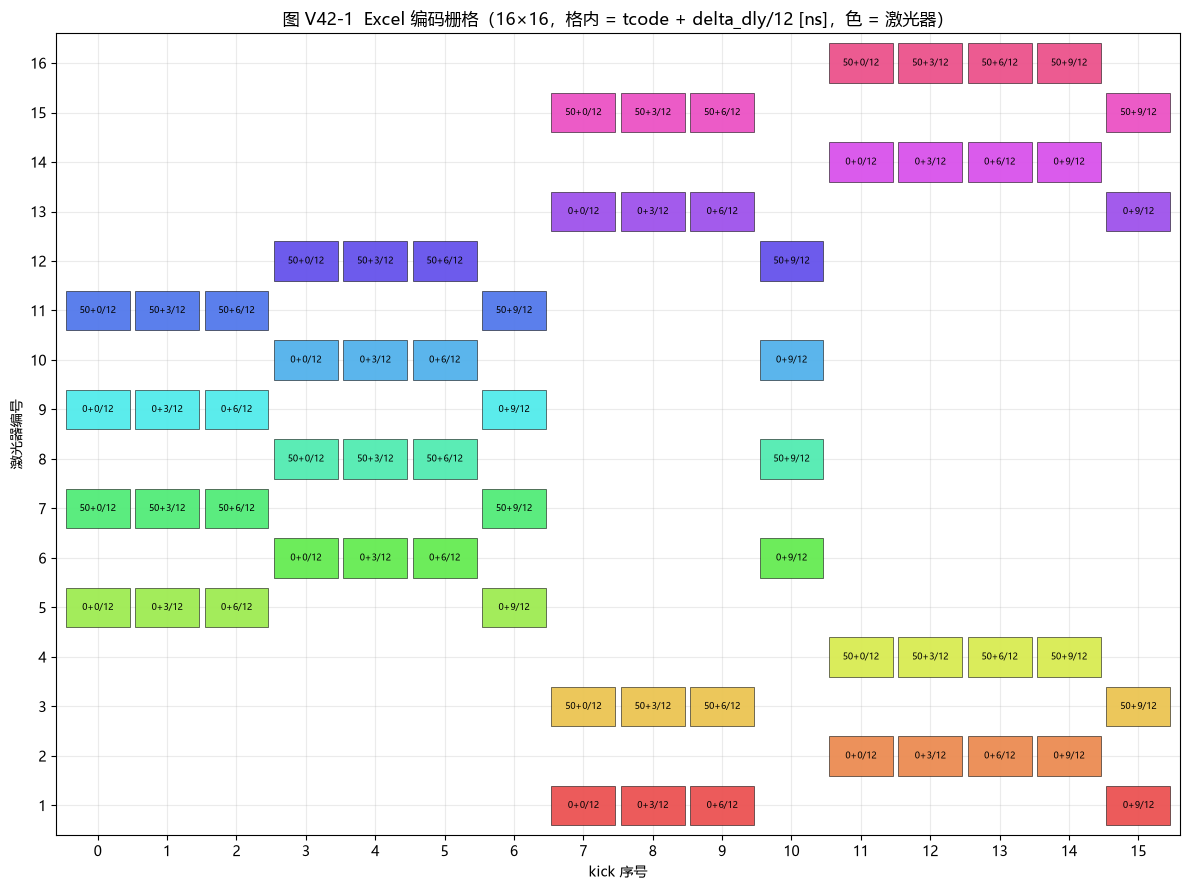

1b. delta_dly（Excel 第4行 tdelay，1/12 ns 步长，按 kick）：
  kick :   0   1   2   3   4   5   6   7   8   9  10  11  12  13  14  15
  delta:   0   3   6   0   3   6   9   0   3   6   9   0   3   6   9   9


In [36]:
# ============================================================================
# 1b. 发光时序 kick 栅格（项目统一风格）
# ============================================================================
# 格内 = tx_trig_dly + delta_dly/12，单位 ns。
#   tx_trig_dly : 1 ns 步长（Excel 各 kick 的发光延时）
#   delta_dly   : 1/12 ns 步长（Excel 第 4 行 tdelay，按 kick 给出，与激光器无关）
def plot_kick_grid(label_of, title):
    fig, ax = plt.subplots(figsize=(12, 9))
    for lid in laser_ids:
        for k in SHOT_KICKS[lid]:
            ax.add_patch(plt.Rectangle(
                (k - 0.46, lid - 0.40), 0.92, 0.80,
                facecolor=laser_color(lid), edgecolor="k",
                linewidth=0.4, alpha=0.95, zorder=2))
            ax.text(k, lid, f"{label_of(lid, k)}", fontsize=6.5,
                    ha="center", va="center", color="k", zorder=3)
    ax.set_xticks(range(16)); ax.set_yticks(laser_ids)
    ax.set_xlim(-0.6, 15.6); ax.set_ylim(0.4, N_LASERS + 0.6)
    ax.set_xlabel("kick 序号")
    ax.set_ylabel("激光器编号")
    ax.set_title(title)
    ax.grid(alpha=0.25, zorder=0); ax.set_axisbelow(True)
    plt.tight_layout(); plt.show()


def code_label(tx_ns, kick):
    return f"{tx_ns}+{tdelay_A.get(kick, 0)}/12"


plot_kick_grid(lambda lid, k: code_label(EXCEL_TX[(lid, k)], k),
               f"图 V42-1  Excel 编码栅格（{N_LASERS}×16，"
               f"格内 = tcode + delta_dly/12 [ns]，色 = 激光器）")

print("1b. delta_dly（Excel 第4行 tdelay，1/12 ns 步长，按 kick）：")
print("  kick : " + " ".join(f"{k:>3d}" for k in range(16)))
print("  delta: " + " ".join(f"{tdelay_A[k]:>3d}" for k in range(16)))


  码表 r1.5: 使用值=[0, 6, 12, 19, 25, 38, 44, 50, 56, 62, 69, 75, 81, 88, 94, 100]  字母表外=无
  码表 r2.5: 使用值=[0, 25, 50, 75, 100]  字母表外=无


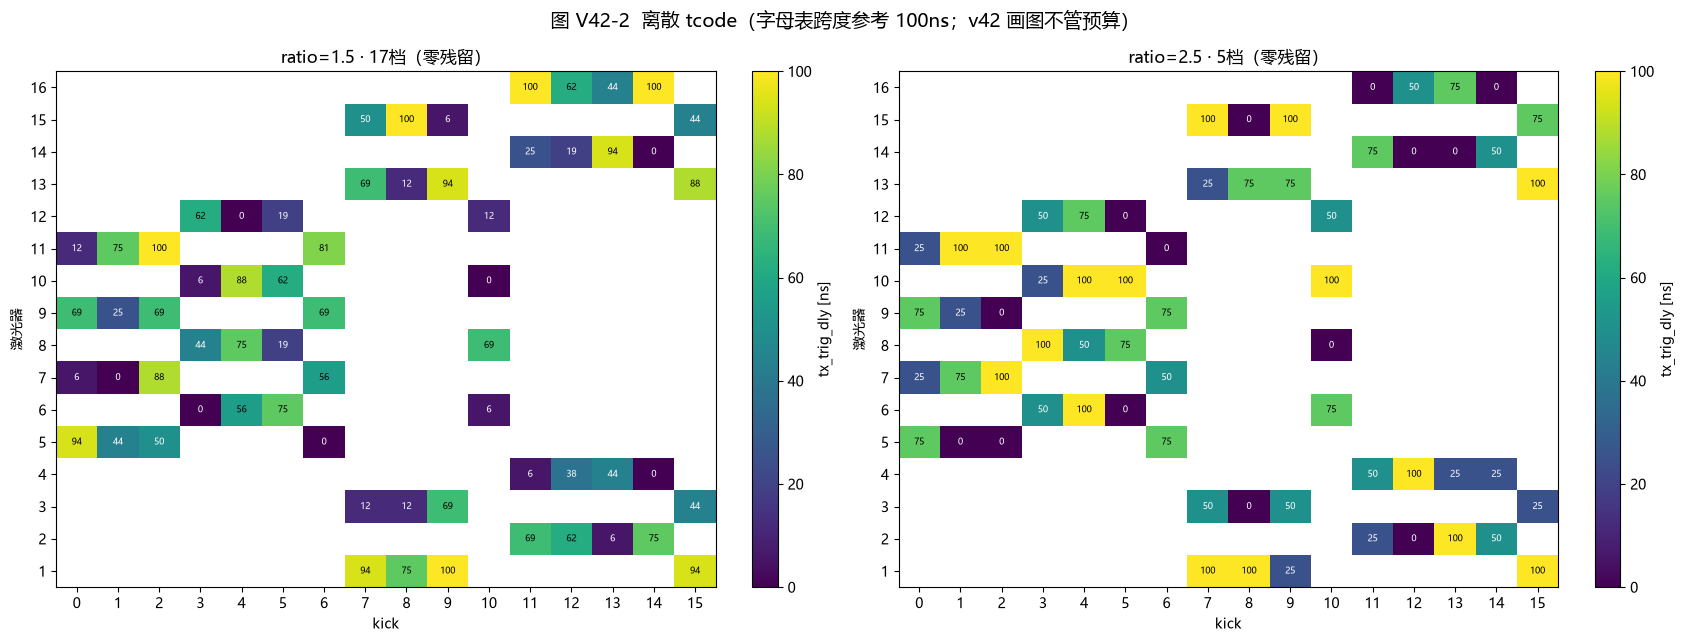

当前 TCODE.ratio_mode=2.5（XM.ratio=2.5），字母表=[0, 25, 50, 75, 100]，预算=100ns


In [37]:
# ============================================================================
# 3. 加载离散字母表码表并画矩阵
#    右：ratio=2.5 / 5 档 [0, 25, 50, 75, 100]（零残留）
#    左：ratio=1.5 / 17 档（零残留；档数更多）
# ============================================================================
TCODE_R15 = {
    (1,7): 94, (1,8): 75, (1,9): 100, (1,15): 94,
    (2,11): 69, (2,12): 62, (2,13):  6, (2,14): 75,
    (3,7): 12, (3,8): 12, (3,9): 69, (3,15): 44,
    (4,11):  6, (4,12): 38, (4,13): 44, (4,14):  0,
    (5,0): 94, (5,1): 44, (5,2): 50, (5,6):  0,
    (6,3):  0, (6,4): 56, (6,5): 75, (6,10):  6,
    (7,0):  6, (7,1):  0, (7,2): 88, (7,6): 56,
    (8,3): 44, (8,4): 75, (8,5): 19, (8,10): 69,
    (9,0): 69, (9,1): 25, (9,2): 69, (9,6): 69,
    (10,3):  6, (10,4): 88, (10,5): 62, (10,10):  0,
    (11,0): 12, (11,1): 75, (11,2): 100, (11,6): 81,
    (12,3): 62, (12,4):  0, (12,5): 19, (12,10): 12,
    (13,7): 69, (13,8): 12, (13,9): 94, (13,15): 88,
    (14,11): 25, (14,12): 19, (14,13): 94, (14,14):  0,
    (15,7): 50, (15,8): 100, (15,9):  6, (15,15): 44,
    (16,11): 100, (16,12): 62, (16,13): 44, (16,14): 100,
}
TCODE_R25 = {
    (1,7): 100, (1,8): 100, (1,9): 25, (1,15): 100,
    (2,11): 25, (2,12):  0, (2,13): 100, (2,14): 50,
    (3,7): 50, (3,8):  0, (3,9): 50, (3,15): 25,
    (4,11): 50, (4,12): 100, (4,13): 25, (4,14): 25,
    (5,0): 75, (5,1):  0, (5,2):  0, (5,6): 75,
    (6,3): 50, (6,4): 100, (6,5):  0, (6,10): 75,
    (7,0): 25, (7,1): 75, (7,2): 100, (7,6): 50,
    (8,3): 100, (8,4): 50, (8,5): 75, (8,10):  0,
    (9,0): 75, (9,1): 25, (9,2):  0, (9,6): 75,
    (10,3): 25, (10,4): 100, (10,5): 100, (10,10): 100,
    (11,0): 25, (11,1): 100, (11,2): 100, (11,6):  0,
    (12,3): 50, (12,4): 75, (12,5):  0, (12,10): 50,
    (13,7): 25, (13,8): 75, (13,9): 75, (13,15): 100,
    (14,11): 75, (14,12):  0, (14,13):  0, (14,14): 50,
    (15,7): 100, (15,8):  0, (15,9): 100, (15,15): 75,
    (16,11):  0, (16,12): 50, (16,13): 75, (16,14):  0,
}

def tcode_lookup(table, lid, kick, default=0):
    return table.get((lid, kick), default)

def active_tcode_table():
    return TCODE_R25 if TCODE["ratio_mode"] == "2.5" else TCODE_R15

def active_alphabet():
    return (TCODE["alphabet_r25"] if TCODE["ratio_mode"] == "2.5"
            else TCODE["alphabet_r15"])

def active_budget():
    return TCODE["budget_ns"]

def active_tx(lid, kick, use_tcode=False):
    if use_tcode:
        return tcode_lookup(active_tcode_table(), lid, kick, 0)
    return EXCEL_TX[(lid, kick)]

for _name, _tbl, _alph in [
        ("r1.5", TCODE_R15, TCODE["alphabet_r15"]),
        ("r2.5", TCODE_R25, TCODE["alphabet_r25"])]:
    _vals = sorted(set(_tbl.values()))
    _bad = [v for v in _vals if v not in _alph]
    print(f"  码表 {_name}: 使用值={_vals}  字母表外={_bad or '无'}")

_vmax = 100
fig, axes = plt.subplots(1, 2, figsize=(17, 6.5))
for ax, (name, table, tag) in zip(
        axes, [(f"ratio=1.5 · 17档", TCODE_R15, "零残留"),
               (f"ratio=2.5 · 5档", TCODE_R25, "零残留")]):
    mat = np.full((N_LASERS, 16), np.nan)
    for i, lid in enumerate(laser_ids):
        for k in SHOT_KICKS[lid]:
            mat[i, k] = table[(lid, k)]
    im = ax.imshow(mat, origin="lower", aspect="auto", cmap="viridis",
                   extent=[-0.5, 15.5, 0.5, 16.5], vmin=0, vmax=_vmax)
    for i, lid in enumerate(laser_ids):
        for k in SHOT_KICKS[lid]:
            v = table[(lid, k)]
            ax.text(k, lid, str(v), ha="center", va="center", fontsize=6.5,
                    color="white" if v < _vmax * 0.55 else "black")
    ax.set_xticks(range(16)); ax.set_yticks(laser_ids)
    ax.set_xlabel("kick"); ax.set_ylabel("激光器")
    ax.set_title(f"{name}（{tag}）")
    fig.colorbar(im, ax=ax, fraction=0.045, label="tx_trig_dly [ns]")
plt.suptitle(f"图 V42-2  离散 tcode（字母表跨度参考 100ns；v42 画图不管预算）", fontsize=14)
plt.tight_layout(); plt.show()
print(f"当前 TCODE.ratio_mode={TCODE['ratio_mode']}（XM.ratio={XM['ratio']}），"
      f"字母表={active_alphabet()}，预算={active_budget()}ns")


In [38]:
# ============================================================================
# 4. 核心仿真与绘图（v42：角度抖动 + 画图100ns）
# ============================================================================
TRUE_COLOR = "#27ae60"
GHOST_COLOR = "#f5b041"
RADAR_COLOR = "#c0392b"


def crosstalk_negligible(emit_laser, recv_laser):
    if not TCODE["consider_gap"]:
        return False
    return abs(emit_laser - recv_laser) > TCODE["max_gap"]


def delta_offset(kick):
    if not TIMING["use_delta_dly"]:
        return 0.0
    return tdelay_A.get(kick, 0) * (NS / 12.0)


def encode_delay_ns(lid, kick, use_tcode=False, cum_ns=None, split=False):
    """kick 后、发光前的编码段 [ns]：FPGA + tcode + delta_dly/12。
    split=True 时返回 (total, fpga_ns, tx_ns, delta_ns)。"""
    tx = active_tx(lid, kick, use_tcode=use_tcode)
    t_tx = tx if TIMING["use_tx_trig_dly"] else 0.0
    d_off = delta_offset(kick) / NS
    d_fpga = 0.0
    if cum_ns is not None and TIMING.get("fpga_in_encode", True):
        d_fpga = float(cum_ns[lid - 1, kick])
    total = d_fpga + t_tx + d_off
    if split:
        return total, d_fpga, t_tx, d_off
    return total


def angle_jitter_ns(angle_deg=None, seed=None, force_ns=None):
    """每个扫角、第一个 tick 之前的整体抖动 [ns]（8ns 步长 × L 档）。"""
    if force_ns is not None:
        return float(force_ns)
    if ANGLE_JITTER.get("value_ns") is not None:
        return float(ANGLE_JITTER["value_ns"])
    if not ANGLE_JITTER.get("enable", False):
        return 0.0
    ang = TIMING.get("scan_angle_deg", 0.0) if angle_deg is None else angle_deg
    sd = ANGLE_JITTER["seed"] if seed is None else seed
    rng = np.random.default_rng(int(sd) + int(round(float(ang) * 1000)) * 10007)
    lvl = int(rng.integers(0, max(1, ANGLE_JITTER["n_levels"])))
    return float(lvl * ANGLE_JITTER["step_ns"])


def build_kick_schedule(use_tcode=False, cum_encode_ns=None,
                        angle_deg=None, angle_jit_ns=None):
    """
    v42 时序链（【每激光器独立】，不共用 kick）：
      对每个激光器 L，按其自己的 SHOT_KICKS[L] 顺序：
        T_kick[L,k] = J_ang 或 上一发 t_fire[L,k_prev] + TOF_FIXED
        enc[L,k]    = FPGA_cum[L,k] + tcode[L,k] + delta   （相加）
        t_fire[L,k] = T_kick[L,k] + enc[L,k]
        下一发立刻：T_kick[L,k_next] = t_fire[L,k] + TOF_FIXED
    不同激光器的 kick 时刻可以完全不同；不再对跨激光器取 max。
    计算用 TOF_FIXED；画图用 plot_tof_ns 压缩。
    """
    all_kicks = sorted(set(k for lid in laser_ids for k in SHOT_KICKS[lid]))
    j_ns = angle_jitter_ns(angle_deg, force_ns=angle_jit_ns)
    firings = []
    # period_map[(lid,k)] = 该激光器本发 kick→下一发 kick 的间隔 [ns]
    period_map = {}
    per_laser_periods = {lid: [] for lid in laser_ids}
    per_laser_end_s = {}

    for lid in laser_ids:
        T = j_ns * NS
        kicks = SHOT_KICKS[lid]
        for ki, k in enumerate(kicks):
            enc_ns, fpga_ns, tx_ns, dly_ns = encode_delay_ns(
                lid, k, use_tcode, cum_encode_ns, split=True)
            d_off = delta_offset(k)
            t_kick = T
            t_fire = t_kick + enc_ns * NS
            firings.append({
                "laser": lid, "kick": k, "tx": tx_ns,
                "encode_ns": enc_ns,
                "fpga_ns": fpga_ns,
                "tx_ns": tx_ns,
                "delta_ns": dly_ns,
                "t_kick": t_kick,
                "t_fire": t_fire,
                "t_ref": t_fire - d_off,
            })
            # 本激光器：TOF 结束后立刻下一 kick
            T_next = t_fire + TOF_FIXED
            period_ns = (T_next - t_kick) / NS   # = enc + TOF_FIXED
            period_map[(lid, k)] = period_ns
            per_laser_periods[lid].append(period_ns)
            T = T_next
        per_laser_end_s[lid] = T

    total_end = max(per_laser_end_s.values()) if per_laser_end_s else 0.0
    net_scan_us = (total_end - j_ns * NS) * 1e6
    # 兼容旧字段：kick_period_ns / kick_times 不再表示「共用踢拍」
    schedule = {
        "kick_period_map": period_map,          # key=(lid,k)
        "per_laser_periods_ns": per_laser_periods,
        "per_laser_end_s": per_laser_end_s,
        "total_scan_us": total_end * 1e6,
        "net_scan_us": net_scan_us,
        "angle_jitter_ns": j_ns,
        "all_kicks": all_kicks,
        "independent_lasers": True,
    }
    budget = TIMING.get("scan_budget_us")
    if budget is not None and not TIMING.get("ignore_budget_in_plot", True):
        schedule["within_budget"] = schedule["total_scan_us"] <= budget
    return firings, schedule


def build_firings(use_tcode=False, cum_encode_ns=None, angle_deg=None, angle_jit_ns=None):
    firings, _ = build_kick_schedule(use_tcode, cum_encode_ns, angle_deg, angle_jit_ns)
    return firings


def detect_echoes(D, firings):
    t_tof = 2.0 * D / C_LIGHT
    recs = []
    for e in firings:
        t_echo = e["t_fire"] + t_tof
        for w in firings:
            if w["t_fire"] <= t_echo <= w["t_fire"] + TOF_WINDOW:
                rec_tof = t_echo - w["t_ref"]
                is_true = (e["laser"] == w["laser"] and e["kick"] == w["kick"])
                recs.append({
                    "emit_laser": e["laser"], "emit_kick": e["kick"],
                    "recv_laser": w["laser"], "recv_kick": w["kick"],
                    "target_D": D, "true_tof": t_tof, "t_echo": t_echo,
                    "rec_tof": rec_tof,
                    "rec_dist": rec_tof * C_LIGHT / 2.0,
                    "is_true": is_true,
                    "negligible": (not is_true) and crosstalk_negligible(
                        e["laser"], w["laser"]),
                    "is_radar": False,
                })
    return recs


def make_fpga_cum(seed, n_levels=None):
    n_levels = FPGA["n_levels"] if n_levels is None else n_levels
    rng = np.random.default_rng(seed)
    if FPGA["shared_across_lasers"]:
        inc_k = rng.integers(0, n_levels, size=16) * FPGA["step_ns"]
        cum_k = FPGA["global_delay_ns"] + np.cumsum(inc_k)
        inc = np.broadcast_to(inc_k, (N_LASERS, 16)).copy()
        cum = np.broadcast_to(cum_k, (N_LASERS, 16)).copy()
    else:
        inc = rng.integers(0, n_levels, size=(N_LASERS, 16)) * FPGA["step_ns"]
        cum = FPGA["global_delay_ns"] + np.cumsum(inc, axis=1)
    return inc, cum


def inject_radar(recs, D, schedule, cum_ours=None, cum_radar=None, phase_ns=None):
    # 对射雷达：相同编码/时序结构，独立 FPGA；落点 mod 本 kick 周期
    if phase_ns is None:
        phase_ns = RADAR["phase_ns"]
    period_map = schedule["kick_period_map"]  # key=(lid,k) 每激光器独立周期
    fallback = TIMING["tof_fixed_us"] * 1000.0
    extra = []
    for lid in laser_ids:
        for k in SHOT_KICKS[lid]:
            d_o = 0.0 if cum_ours is None else float(cum_ours[lid - 1, k])
            d_r = 0.0 if cum_radar is None else float(cum_radar[lid - 1, k])
            period = period_map.get((lid, k), period_map.get(k, fallback))
            tof_ns = float(np.mod(phase_ns + d_r - d_o, period))
            if 0.0 <= tof_ns <= (TOF_WINDOW / NS):
                extra.append({
                    "emit_laser": -1, "emit_kick": -1,
                    "recv_laser": lid, "recv_kick": k,
                    "target_D": D, "true_tof": 0.0, "t_echo": 0.0,
                    "rec_tof": tof_ns * NS,
                    "rec_dist": tof_ns * NS * C_LIGHT / 2.0,
                    "is_true": False, "negligible": False, "is_radar": True,
                })
    return list(recs) + extra


def echo_amp(rec):
    return 1.0


def rec_bin(rec):
    return int(np.clip(np.floor(rec["rec_tof"] / NS / HIST_BIN_NS), 0, N_BINS - 1))


def build_hists(recs):
    # v30：XM.use_pulse_width=False → 每条回波只占 1 个 bin（理想 δ）
    H = {lid: np.zeros((len(SHOT_KICKS[lid]), N_BINS)) for lid in laser_ids}
    src = {lid: defaultdict(list) for lid in laser_ids}
    shot_idx = {lid: {k: i for i, k in enumerate(SHOT_KICKS[lid])}
                for lid in laser_ids}
    for r in recs:
        if (not r["is_true"]) and r["negligible"] and (not XM["use_negligible"]):
            continue
        lid = r["recv_laser"]
        b = rec_bin(r)
        if XM["use_pulse_width"]:
            # 预留：按脉宽展宽；v30 默认关闭
            half = int(round(XM["pulse_width_ns"] / HIST_BIN_NS / 2))
            for db in range(-half, half + 1):
                bb = int(np.clip(b + db, 0, N_BINS - 1))
                H[lid][shot_idx[lid][r["recv_kick"]], bb] += echo_amp(r)
                src[lid][bb].append(r)
        else:
            H[lid][shot_idx[lid][r["recv_kick"]], b] += echo_amp(r)
            src[lid][b].append(r)
    return {lid: {
        "shots": H[lid],
        "add": H[lid].sum(axis=0),
        "max": H[lid].max(axis=0),
        "src": src[lid],
        "kicks": SHOT_KICKS[lid],
    } for lid in laser_ids}


def find_peaks(y, th=0.5):
    above = np.asarray(y) > th
    if not above.any():
        return []
    idx = np.flatnonzero(above)
    brk = np.flatnonzero(np.diff(idx) > 1)
    return list(zip(np.concatenate(([idx[0]], idx[brk + 1])).tolist(),
                    np.concatenate((idx[brk], [idx[-1]])).tolist()))


def crosstalk_mark(h, ratio=None):
    ratio = XM["ratio"] if ratio is None else ratio
    add, mx = h["add"], h["max"]
    thresh = mx * ratio
    after, peaks = add.copy(), []
    for (s, e) in find_peaks(add):
        p = s + int(np.argmax(add[s:e + 1]))
        add_p, max_p = float(add[p]), float(mx[p])
        is_xtalk = bool(max_p * ratio > add_p)
        if is_xtalk:
            after[s:e + 1] = 0.0
        peaks.append({
            "s": s, "e": e, "peak_bin": p, "dist": p * HIST_BIN_M,
            "add": add_p, "max": max_p,
            "ratio": add_p / max(max_p, 1e-9), "is_xtalk": is_xtalk,
        })
    return {"thresh": thresh, "peaks": peaks, "after": after}


def crosstalk_mark_all(hs, ratio=None):
    return {lid: crosstalk_mark(h, ratio) for lid, h in hs.items()}


def rec_kind(rec):
    if rec.get("is_true"):
        return "true"
    if rec.get("is_radar"):
        return "radar"
    return "ghost"


def rec_style(rec, alpha=0.92):
    kind = rec_kind(rec)
    if kind == "true":
        return dict(facecolor=TRUE_COLOR, edgecolor="black",
                    linewidth=1.8, hatch=None, alpha=alpha)
    if kind == "radar":
        return dict(facecolor=RADAR_COLOR, edgecolor="#7b241c",
                    linewidth=1.1, hatch="///", alpha=alpha)
    return dict(facecolor=GHOST_COLOR, edgecolor="black",
                linewidth=0.8, hatch=None, alpha=alpha)


def rec_label(rec):
    kind = rec_kind(rec)
    if kind == "true":
        return f"真L{rec['emit_laser']}K{rec['emit_kick']}"
    if kind == "radar":
        return f"对射K{rec['recv_kick']}"
    return f"鬼L{rec['emit_laser']}K{rec['emit_kick']}"


def type_legend():
    return [
        Patch(facecolor=TRUE_COLOR, edgecolor="black", linewidth=1.8,
              label="真实信号（绿、粗黑边）"),
        Patch(facecolor=GHOST_COLOR, edgecolor="black", linewidth=0.8,
              label="模组内鬼影（橙）"),
        Patch(facecolor=RADAR_COLOR, edgecolor="#7b241c", hatch="///",
              label="雷达对射（红、斜线）"),
        plt.Line2D([0], [0], marker="x", color="black", ls="none",
                   markersize=9, markeredgewidth=2, label="被 XM 丢掉"),
    ]


def peak_for_bin(rr, b):
    return next((q for q in rr["peaks"] if q["s"] <= b <= q["e"]), None)


def count_peak_types(hs, rs):
    c = Counter()
    for lid, rr in rs.items():
        for q in rr["peaks"]:
            recs = [r for b in range(q["s"], q["e"] + 1)
                    for r in hs[lid]["src"].get(b, [])]
            n_true = sum(1 for r in recs if r.get("is_true"))
            n_radar = sum(1 for r in recs if r.get("is_radar"))
            n_ghost = len(recs) - n_true - n_radar
            if n_true and not n_radar and not n_ghost:
                kind = "纯真峰"
            elif n_radar and not n_true and not n_ghost:
                kind = "纯对射峰"
            elif n_ghost and not n_true and not n_radar:
                kind = "纯鬼峰"
            else:
                kind = "混合峰"
            act = "丢弃" if q["is_xtalk"] else "保留"
            c[(kind, act)] += 1
    return c


def print_stats(tag, hs, rs):
    c = count_peak_types(hs, rs)
    print(f"\n【{tag}】峰级统计")
    print(f"  {'类型':>8} {'保留':>6} {'丢弃':>6}")
    for k in ["纯真峰", "纯鬼峰", "纯对射峰", "混合峰"]:
        print(f"  {k:>8} {c[(k,'保留')]:>6d} {c[(k,'丢弃')]:>6d}")
    return c


def occupied_range(hs, pad=20):
    lo, hi = N_BINS, 0
    for h in hs.values():
        nz = np.flatnonzero(h["add"] > 0)
        if len(nz):
            lo = min(lo, int(nz.min()))
            hi = max(hi, int(nz.max()))
    if lo > hi:
        return 0, N_BINS - 1
    return max(0, lo - pad), min(N_BINS - 1, hi + pad)


def run_scene(use_tcode=False, use_fpga=False, D=None, phase_ns=None,
              seed_ours=None, seed_radar=None,
              angle_deg=None, angle_jit_ns=None, n_fpga_levels=None):
    if D is None:
        D = SCENE["demo_D_m"]
    if angle_deg is not None:
        TIMING["scan_angle_deg"] = angle_deg
    cum_o = cum_r = inc_o = inc_r = None
    so = FPGA["seed_ours"] if seed_ours is None else seed_ours
    sr = FPGA["seed_radar"] if seed_radar is None else seed_radar
    if use_fpga:
        inc_o, cum_o = make_fpga_cum(so, n_levels=n_fpga_levels)
        inc_r, cum_r = make_fpga_cum(sr, n_levels=n_fpga_levels)
    cum_enc = cum_o if (use_fpga and TIMING.get("fpga_in_encode", True)) else None
    firings, schedule = build_kick_schedule(
        use_tcode=use_tcode, cum_encode_ns=cum_enc,
        angle_deg=angle_deg, angle_jit_ns=angle_jit_ns)
    recs = detect_echoes(D, firings)
    if RADAR["enable"]:
        recs = inject_radar(recs, D, schedule, cum_ours=cum_o, cum_radar=cum_r,
                            phase_ns=phase_ns)
    hs = build_hists(recs)
    rs = crosstalk_mark_all(hs, XM["ratio"])
    return {"recs": recs, "hs": hs, "rs": rs, "D": D,
            "schedule": schedule, "firings": firings,
            "inc_ours": inc_o, "cum_ours": cum_o,
            "inc_radar": inc_r, "cum_radar": cum_r,
            "use_tcode": use_tcode, "use_fpga": use_fpga,
            "seed_ours": so if use_fpga else None,
            "seed_radar": sr if use_fpga else None,
            "angle_jitter_ns": schedule.get("angle_jitter_ns", 0.0)}


def plot_timing_timeline(firings, schedule, title, cum_radar=None, show_radar=True,
                         use_plot_tof=True):
    """每激光器独立时序链（不共用 kick）。

    对激光器 L 的第 i 发：
      T_kick → enc=FPGA+tcode+delta（相加）→ t_fire → TOF → 立刻下一发 T_kick
    画图时 TOF 用 plot_tof_ns 压缩；计算仍用 TOF_FIXED。
    不同激光器的 kick 时刻可以错开。
    """
    fig, ax = plt.subplots(figsize=(15, 6.2))
    ymap = {lid: i for i, lid in enumerate(laser_ids)}
    enc_h, fire_h, tof_h = 0.20, 0.26, 0.16
    tof_draw_us = (PLOT_TOF_NS * 1e-3) if use_plot_tof else TIMING["tof_fixed_us"]
    j_ns = schedule.get("angle_jitter_ns", 0.0)
    tof_calc_us = TIMING["tof_fixed_us"]

    # 按激光器分组，保持 SHOT_KICKS 顺序
    by_laser = {lid: [] for lid in laser_ids}
    for f in firings:
        by_laser[f["laser"]].append(f)
    for lid in laser_ids:
        order = {k: i for i, k in enumerate(SHOT_KICKS[lid])}
        by_laser[lid].sort(key=lambda f: order.get(f["kick"], f["kick"]))

    # 画图时间轴：每激光器独立递推
    # t_kick_plot[(lid,k)], t_fire_plot[(lid,k)]
    t_kick_plot, t_fire_plot = {}, {}
    for lid in laser_ids:
        if use_plot_tof:
            T = j_ns * 1e-3
            for f in by_laser[lid]:
                t_kick_plot[(lid, f["kick"])] = T
                tf = T + f["encode_ns"] * 1e-3
                t_fire_plot[(lid, f["kick"])] = tf
                T = tf + tof_draw_us          # 本激光器 TOF 完立刻下一发
        else:
            for f in by_laser[lid]:
                t_kick_plot[(lid, f["kick"])] = f["t_kick"] * 1e6
                t_fire_plot[(lid, f["kick"])] = f["t_fire"] * 1e6

    if j_ns > 0:
        ax.axvspan(0, j_ns * 1e-3, color="#f9e79f", alpha=0.45, zorder=0,
                   label=f"角度抖动 J_ang={j_ns:.0f}ns")

    first = {"fpga": True, "tcode": True, "tof": True, "next": True}
    for lid in laser_ids:
        y = ymap[lid]
        for f in by_laser[lid]:
            k = f["kick"]
            t0 = t_kick_plot[(lid, k)]
            fpga_us = float(f.get("fpga_ns", 0.0)) * 1e-3
            tx_us = float(f.get("tx_ns", f.get("tx", 0.0))) * 1e-3
            dly_us = float(f.get("delta_ns", 0.0)) * 1e-3
            enc_us = f["encode_ns"] * 1e-3
            t_fire = t_fire_plot[(lid, k)]

            x = t0
            if fpga_us > 1e-9:
                ax.barh(y, fpga_us, left=x, height=enc_h, color="#bb8fce",
                        edgecolor="#5b2c6f", linewidth=0.4,
                        label="FPGA累计" if first["fpga"] else "")
                first["fpga"] = False
                x += fpga_us
            if tx_us > 1e-9:
                ax.barh(y, tx_us, left=x, height=enc_h, color="#aed6f1",
                        edgecolor="#1a5276", linewidth=0.4,
                        label="tcode" if first["tcode"] else "")
                first["tcode"] = False
                x += tx_us
            if dly_us > 1e-9:
                ax.barh(y, dly_us, left=x, height=enc_h, color="#a3e4d7",
                        edgecolor="#0e6655", linewidth=0.4)

            ax.barh(y + 0.30, max(enc_us, 1e-6), left=t0, height=fire_h,
                    color=laser_color(lid), edgecolor="k", linewidth=0.35, alpha=0.85)
            ax.barh(y + 0.30, tof_draw_us, left=t_fire, height=tof_h,
                    color="#d5dbdb", edgecolor="gray", linewidth=0.4,
                    label=(f"TOF画图{PLOT_TOF_NS:.0f}ns（算{tof_calc_us}μs）"
                           if first["tof"] else ""))
            first["tof"] = False

            # 本激光器：TOF 结束点 = 下一发 kick（红短线，只画在该行）
            tend = t_fire + tof_draw_us
            ax.plot([tend, tend], [y - 0.05, y + 0.55], color="#c0392b",
                    lw=1.2, alpha=0.7,
                    label="本激光器TOF完=下一发kick" if first["next"] else "")
            first["next"] = False
            ax.plot([t0, t0], [y - 0.05, y + 0.55], "k--", lw=0.55, alpha=0.4)
            ax.text(t0, y - 0.28, f"K{k}", fontsize=6, ha="center", color="#1a5276")
            # 间隔标注：enc+TOF（该激光器自己的）
            ax.text(t0 + 0.5 * (enc_us + tof_draw_us), y + 0.62,
                    f"Δ=enc{f['encode_ns']:.0f}+TOF",
                    fontsize=5.5, ha="center", color="#566573")

    if show_radar and RADAR["enable"] and cum_radar is not None:
        ax.axhline(len(laser_ids) + 0.55, color=RADAR_COLOR, ls=":", lw=1.2, alpha=0.6)
        ax.text(0.02, len(laser_ids) + 0.60, "对射：同编码规则，独立FPGA；周期=该激光器自己的enc+TOF",
                transform=ax.get_yaxis_transform(), fontsize=8, color=RADAR_COLOR)

    ax.set_yticks([ymap[l] + 0.30 for l in laser_ids])
    ax.set_yticklabels([f"L{l}" for l in laser_ids])
    ax.set_ylim(-0.7, len(laser_ids) + 0.9)
    if use_plot_tof:
        ax.set_xlabel(
            f"画图时间 [μs]（每激光器独立链；间隔=该路enc+{PLOT_TOF_NS:.0f}ns；"
            f"计算间隔=该路enc+{tof_calc_us}μs）")
    else:
        ax.set_xlabel("时间 [μs]（真实计算尺度；每激光器独立）")

    # 画图链长 = 各激光器压缩链的最大末端
    plot_ends = []
    for lid in laser_ids:
        if by_laser[lid]:
            f = by_laser[lid][-1]
            plot_ends.append(t_fire_plot[(lid, f["kick"])] + tof_draw_us)
    plot_span = (max(plot_ends) - j_ns * 1e-3) if plot_ends else 0.0
    ax.set_title(
        title
        + f"  画图≈{plot_span:.3f}μs"
        + f"  计算净时长={schedule.get('net_scan_us', schedule['total_scan_us']):.2f}μs"
        + f"  J_ang={j_ns:.0f}ns  【每激光器独立kick】")
    if (not TIMING.get("ignore_budget_in_plot", True)) and TIMING.get("scan_budget_us"):
        ax.axvline(TIMING["scan_budget_us"], color="#e74c3c", ls="--", lw=1.0,
                   label=f"扫角预算 {TIMING['scan_budget_us']}μs")
    ax.legend(loc="upper right", fontsize=7, ncol=2)
    ax.grid(alpha=0.2, axis="x")
    plt.tight_layout()
    plt.show()

    print(f"  J_ang={j_ns:.0f}ns；每激光器独立：间隔 = 该路(FPGA+tcode+delta) + TOF")
    print(f"  画图TOF={PLOT_TOF_NS:.0f}ns；计算TOF_FIXED={tof_calc_us}μs")
    # 打印每激光器各发间隔（证明互不等待）
    for lid in laser_ids[:4]:
        periods = schedule.get("per_laser_periods_ns", {}).get(lid, [])
        encs = [f["encode_ns"] for f in by_laser[lid]]
        fpgas = [f.get("fpga_ns", 0.0) for f in by_laser[lid]]
        kicks = [f["kick"] for f in by_laser[lid]]
        print(f"  L{lid} kicks={kicks}")
        print(f"       enc(FPGA+tcode)={['%.0f'%e for e in encs]}  "
              f"FPGA部分={['%.0f'%e for e in fpgas]}")
        print(f"       间隔ns(enc+TOF_calc)={['%.0f'%p for p in periods]}")
    if len(laser_ids) > 4:
        print(f"  … 共 {len(laser_ids)} 个激光器（上仅列前4路）")
    print(f"  计算净扫角时长(最慢那路墙钟) {schedule.get('net_scan_us', schedule['total_scan_us']):.2f}μs")



def plot_echo_grid(hs, rs, title, D, zoom_plot_tof=True):
    # 16 宫格逐回波堆叠柱 + XM 黑叉
    # v42：默认缩到真目标 ±plot_tof_ns，否则编码细节看不清
    if zoom_plot_tof:
        b_lo, b_hi = plot_window_bins(D)
    else:
        b_lo, b_hi = occupied_range(hs, pad=20)
    nrow = int(np.ceil(N_LASERS / 4))
    fig, axes = plt.subplots(nrow, 4, figsize=(22, 3.2 * nrow), sharex=True)
    axes = np.atleast_2d(axes)
    radar_m = RADAR["phase_ns"] * NS * C_LIGHT / 2.0
    ymax = 1
    for i, lid in enumerate(laser_ids):
        ax = axes[i // 4][i % 4]
        h, rr = hs[lid], rs[lid]
        for b in range(b_lo, b_hi + 1):
            q = peak_for_bin(rr, b)
            dropped = bool(q and q["is_xtalk"])
            for level, rec in enumerate(h["src"].get(b, [])):
                xc = b * HIST_BIN_M
                st = rec_style(rec, alpha=0.20 if dropped else 0.92)
                ax.add_patch(plt.Rectangle(
                    (xc - 0.55, level), 1.1, 0.86, zorder=3, **st))
                if not dropped:
                    ax.text(xc, level + 0.43, rec_label(rec),
                            ha="center", va="center", fontsize=4.6, zorder=4)
                ymax = max(ymax, level + 1)
        for q in rr["peaks"]:
            if q["is_xtalk"]:
                ax.plot(q["dist"], q["add"] + 0.18, "kx", ms=8, mew=1.7, zorder=6)
        ax.axvline(D, color="k", ls=":", lw=0.9, alpha=0.7)
        ax.axvline(radar_m, color=RADAR_COLOR, ls="--", lw=0.8, alpha=0.35)
        n_drop = sum(1 for q in rr["peaks"] if q["is_xtalk"])
        n_keep = sum(1 for q in rr["peaks"] if not q["is_xtalk"])
        ax.set_title(f"L{lid}: 留{n_keep}/丢{n_drop}", fontsize=9)
        ax.tick_params(labelsize=7); ax.grid(alpha=0.16, axis="x")
    for j in range(N_LASERS, nrow * 4):
        axes[j // 4][j % 4].axis("off")
    for i in range(N_LASERS):
        axes[i // 4][i % 4].set_ylim(0, ymax + 0.8)
    fig.legend(handles=type_legend(), loc="upper center", ncol=4, fontsize=9)
    fig.text(0.5, 0.01,
             f"逐回波堆叠柱；黑点线=真目标 {D:.0f}m；红虚线=对射名义；"
             f"黑叉=XM滤除；XM_RATIO={XM['ratio']}",
             ha="center", fontsize=11)
    plt.suptitle(title, fontsize=14, y=0.995)
    plt.tight_layout(rect=[0, 0.03, 1, 0.93])
    plt.show()


def plot_echo_channel(hs, rs, lid, title, D, zoom_plot_tof=True):
    h, rr = hs[lid], rs[lid]
    if zoom_plot_tof:
        b_lo, b_hi = plot_window_bins(D)
    else:
        b_lo, b_hi = occupied_range({lid: h}, pad=30)
    radar_m = RADAR["phase_ns"] * NS * C_LIGHT / 2.0
    fig, ax = plt.subplots(figsize=(14, 4.2))
    ymax = 1
    for b in range(b_lo, b_hi + 1):
        q = peak_for_bin(rr, b)
        dropped = bool(q and q["is_xtalk"])
        for level, rec in enumerate(h["src"].get(b, [])):
            xc = b * HIST_BIN_M
            st = rec_style(rec, alpha=0.20 if dropped else 0.92)
            ax.add_patch(plt.Rectangle(
                (xc - 0.55, level), 1.1, 0.86, zorder=3, **st))
            if not dropped:
                ax.text(xc, level + 0.43, rec_label(rec),
                        ha="center", va="center", fontsize=6, zorder=4)
            ymax = max(ymax, level + 1)
    for q in rr["peaks"]:
        if q["is_xtalk"]:
            ax.plot(q["dist"], q["add"] + 0.18, "kx", ms=10, mew=2.0, zorder=6)
    ax.axvline(D, color="k", ls=":", lw=1.3, label=f"真目标 {D:.0f}m")
    ax.axvline(radar_m, color=RADAR_COLOR, ls="--", lw=1.1, alpha=0.45,
               label=f"对射名义 {radar_m:.0f}m")
    # 是否叠峰
    sep_m = TCODE["sep_ns"] * NS * C_LIGHT / 2.0
    overlap = abs(radar_m - D) < sep_m
    ax.set_ylim(0, ymax + 0.9)
    ax.set_xlabel("记录距离 rec_dist [m]")
    ax.set_ylabel("同距离回波堆叠层数")
    ax.set_title(title + (f"  ［对射与真峰|Δ|={abs(radar_m-D):.1f}m"
                          + ("，落入峰宽" if overlap else "，未叠峰") + "］"))
    ax.legend(handles=type_legend(), fontsize=8, ncol=4)
    ax.grid(alpha=0.2, axis="x")
    plt.tight_layout(); plt.show()


def plot_true_radar_stack(hs, rs, lid, title, D):
    """图 iii-c 专用：只画真回波 + 对射（堆叠柱标准），并标每个对射 kick 是否落入真峰±SEP。"""
    h, rr = hs[lid], rs[lid]
    sep_m = TCODE["sep_ns"] * NS * C_LIGHT / 2.0
    # 只收集真 / 对射
    bins = {}
    for b, recs in h["src"].items():
        keep = [r for r in recs if r.get("is_true") or r.get("is_radar")]
        if keep:
            bins[b] = keep
    if not bins:
        print(f"（L{lid} 无真/对射回波可画）")
        return
    b_lo, b_hi = plot_window_bins(D)
    if min(bins) < b_lo or max(bins) > b_hi:
        b_lo = max(0, min(bins) - 25)
        b_hi = min(N_BINS - 1, max(bins) + 25)
    fig, ax = plt.subplots(figsize=(14, 4.2))
    ymax = 1
    radar_dists = []
    for b in range(b_lo, b_hi + 1):
        q = peak_for_bin(rr, b)
        dropped = bool(q and q["is_xtalk"])
        for level, rec in enumerate(bins.get(b, [])):
            xc = b * HIST_BIN_M
            st = rec_style(rec, alpha=0.22 if dropped else 0.95)
            ax.add_patch(plt.Rectangle(
                (xc - 0.55, level), 1.1, 0.86, zorder=3, **st))
            lab = rec_label(rec)
            if not dropped:
                ax.text(xc, level + 0.43, lab, ha="center", va="center",
                        fontsize=7, zorder=4)
            ymax = max(ymax, level + 1)
            if rec.get("is_radar"):
                radar_dists.append((rec["recv_kick"], xc, dropped,
                                    abs(xc - D) < sep_m))
    for q in rr["peaks"]:
        if q["is_xtalk"] and any(q["s"] <= b <= q["e"] for b in bins):
            ax.plot(q["dist"], q["add"] + 0.18, "kx", ms=10, mew=2.0, zorder=6)
    ax.axvline(D, color="k", ls=":", lw=1.5, label=f"真目标 {D:.0f}m")
    ax.axvspan(D - sep_m, D + sep_m, color="k", alpha=0.08,
               label=f"真峰±SEP({TCODE['sep_ns']}ns≈{sep_m:.2f}m)")
    n_ov = sum(1 for *_, ov in radar_dists if ov)
    n_drop = sum(1 for *_, dropped, _ in radar_dists if dropped)
    ax.set_ylim(0, ymax + 1.0)
    ax.set_xlabel("记录距离 rec_dist [m]")
    ax.set_ylabel("同距离回波堆叠层数")
    ax.set_title(title + f"  ［对射{len(radar_dists)}条：落入真峰宽{n_ov}，XM丢掉{n_drop}］")
    ax.legend(handles=type_legend() + [
        Patch(facecolor="k", alpha=0.08, label=f"真峰±SEP"),
    ], fontsize=8, ncol=4)
    ax.grid(alpha=0.2, axis="x")
    # 逐 kick 文字说明
    if radar_dists:
        lines = []
        for k, d, dropped, ov in sorted(radar_dists):
            lines.append(f"K{k}:{d:.1f}m"
                         + ("·叠真峰" if ov else "")
                         + ("·XM丢" if dropped else "·XM留"))
        ax.text(0.01, 0.98, "  ".join(lines), transform=ax.transAxes,
                fontsize=8, va="top", ha="left",
                bbox=dict(boxstyle="round", facecolor="white", alpha=0.75))
    plt.tight_layout(); plt.show()


print("4. 核心函数已加载（v42：角度抖动 + 画图100ns）")
print(f"  直方图 {N_BINS} bins × {HIST_BIN_NS:.0f}ns（计算窗={TIMING['tof_window_ns']:.0f}ns），"
      f"画图局部窗=±{PLOT_TOF_NS:.0f}ns≈±{PLOT_TOF_M:.1f}m，"
      f"XM.use_pulse_width={XM['use_pulse_width']}")
print(f"  consider_gap={TCODE['consider_gap']}  ANGLE_JITTER.enable={ANGLE_JITTER['enable']}")


4. 核心函数已加载（v42：角度抖动 + 画图100ns）
  直方图 2000 bins × 1ns（计算窗=2000ns），画图局部窗=±100ns≈±15.0m，XM.use_pulse_width=False
  consider_gap=True  ANGLE_JITTER.enable=True


In [39]:
# ============================================================================
# 3b. 一字滤波
# ============================================================================
def xm_kept_peaks(rs, lid):
    return [dict(q) for q in rs[lid]["peaks"] if not q["is_xtalk"]]


def nearest_abs_dist(d, peaks):
    if not peaks:
        return float("inf")
    return float(min(abs(d - p["dist"]) for p in peaks))


def line_filter_all(rs_L, rs_M, rs_R, thr_m=None):
    thr_m = LINE["thr_m"] if thr_m is None else thr_m
    out = {}
    for lid in laser_ids:
        peaks_L = xm_kept_peaks(rs_L, lid)
        peaks_M = xm_kept_peaks(rs_M, lid)
        peaks_R = xm_kept_peaks(rs_R, lid)
        kept = []
        after = rs_M[lid]["after"].copy()
        for q in peaks_M:
            dL = nearest_abs_dist(q["dist"], peaks_L)
            dR = nearest_abs_dist(q["dist"], peaks_R)
            iso = (dL > thr_m) and (dR > thr_m)
            qq = dict(q)
            qq["dL"], qq["dR"] = dL, dR
            qq["is_line_ghost"] = bool(iso)
            if iso:
                after[q["s"]:q["e"] + 1] = 0.0
            kept.append(qq)
        out[lid] = {"peaks": kept, "after_xm": rs_M[lid]["after"],
                    "after_line": after}
    return out


def summarize_line(tag, line_res, hs_M):
    n_true_keep = n_fake_drop = n_fake_keep = n_ghost_keep = 0
    for lid, rr in line_res.items():
        for q in rr["peaks"]:
            recs = [r for b in range(q["s"], q["e"] + 1)
                    for r in hs_M[lid]["src"].get(b, [])]
            is_fake = any(r.get("is_radar") for r in recs)
            is_true = any(r.get("is_true") for r in recs)
            is_ghost = (not is_true) and (not is_fake) and len(recs) > 0
            if q["is_line_ghost"]:
                if is_fake:
                    n_fake_drop += 1
            else:
                if is_true and not is_fake:
                    n_true_keep += 1
                if is_fake:
                    n_fake_keep += 1
                if is_ghost:
                    n_ghost_keep += 1
    print(f"\n【{tag}】一字滤波 thr={LINE['thr_m']:.1f}m")
    print(f"  真峰留下 {n_true_keep}；对射留下 {n_fake_keep} / 丢掉 {n_fake_drop}；"
          f"鬼影留下 {n_ghost_keep}")
    return {"true_keep": n_true_keep, "fake_keep": n_fake_keep,
            "fake_drop": n_fake_drop, "ghost_keep": n_ghost_keep}


print("3b. 一字滤波函数已加载")


3b. 一字滤波函数已加载


# 3c. 时序链演示

kick 只触发；**编码在 kick 后、发光前**；发光后等固定 $2.2\,\mu s$ TOF 段；下一 kick 间隔 $=\max\mathrm{enc}+2.2\,\mu s$（随 tcode 变化）。
对射雷达采用相同编码结构。

3c. J_ang=48ns；计算TOF=2.2μs；画图按100ns压缩；independent_lasers=True


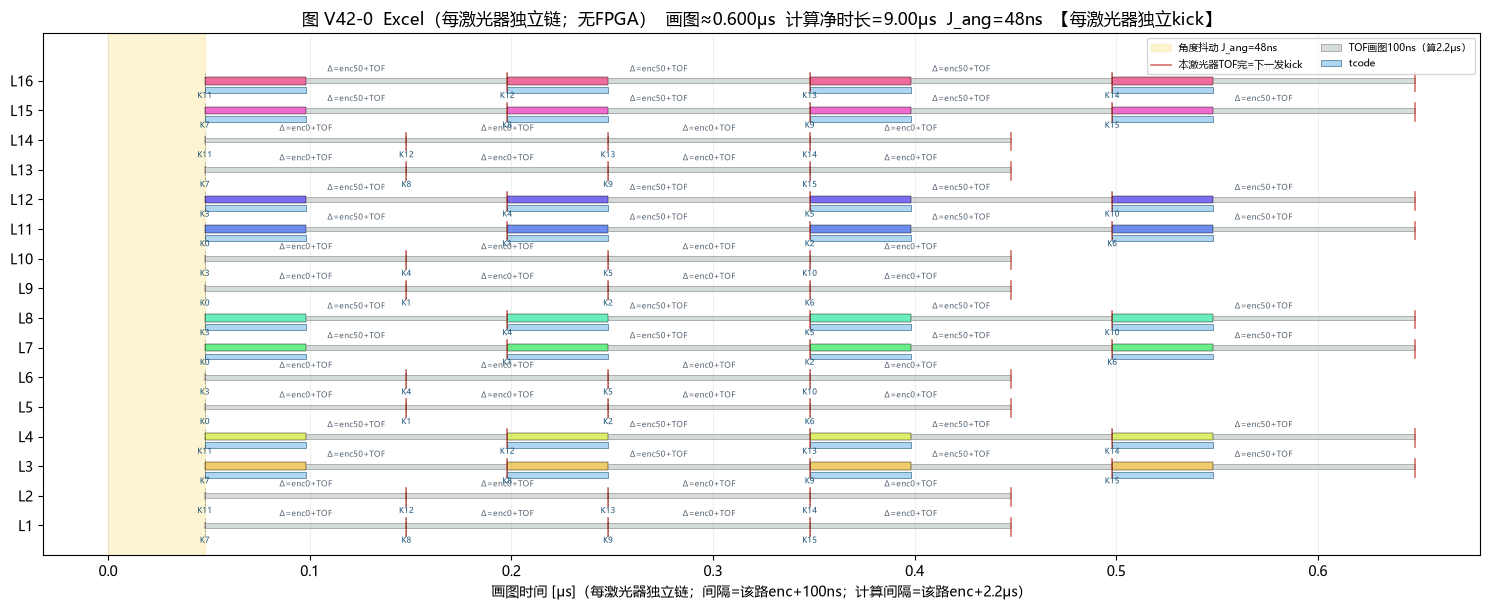

  J_ang=48ns；每激光器独立：间隔 = 该路(FPGA+tcode+delta) + TOF
  画图TOF=100ns；计算TOF_FIXED=2.2μs
  L1 kicks=[7, 8, 9, 15]
       enc(FPGA+tcode)=['0', '0', '0', '0']  FPGA部分=['0', '0', '0', '0']
       间隔ns(enc+TOF_calc)=['2200', '2200', '2200', '2200']
  L2 kicks=[11, 12, 13, 14]
       enc(FPGA+tcode)=['0', '0', '0', '0']  FPGA部分=['0', '0', '0', '0']
       间隔ns(enc+TOF_calc)=['2200', '2200', '2200', '2200']
  L3 kicks=[7, 8, 9, 15]
       enc(FPGA+tcode)=['50', '50', '50', '50']  FPGA部分=['0', '0', '0', '0']
       间隔ns(enc+TOF_calc)=['2250', '2250', '2250', '2250']
  L4 kicks=[11, 12, 13, 14]
       enc(FPGA+tcode)=['50', '50', '50', '50']  FPGA部分=['0', '0', '0', '0']
       间隔ns(enc+TOF_calc)=['2250', '2250', '2250', '2250']
  … 共 16 个激光器（上仅列前4路）
  计算净扫角时长(最慢那路墙钟) 9.00μs
3c-0b. enc=FPGA_cum+tcode（相加）；每激光器自己的 kick 时刻可不同
  本角 FPGA 累计 [ns] kick0..15（shared_across_lasers=True）:
       8    16    64    88   112   112   152   184   192   240   248   296   296   312   360   360


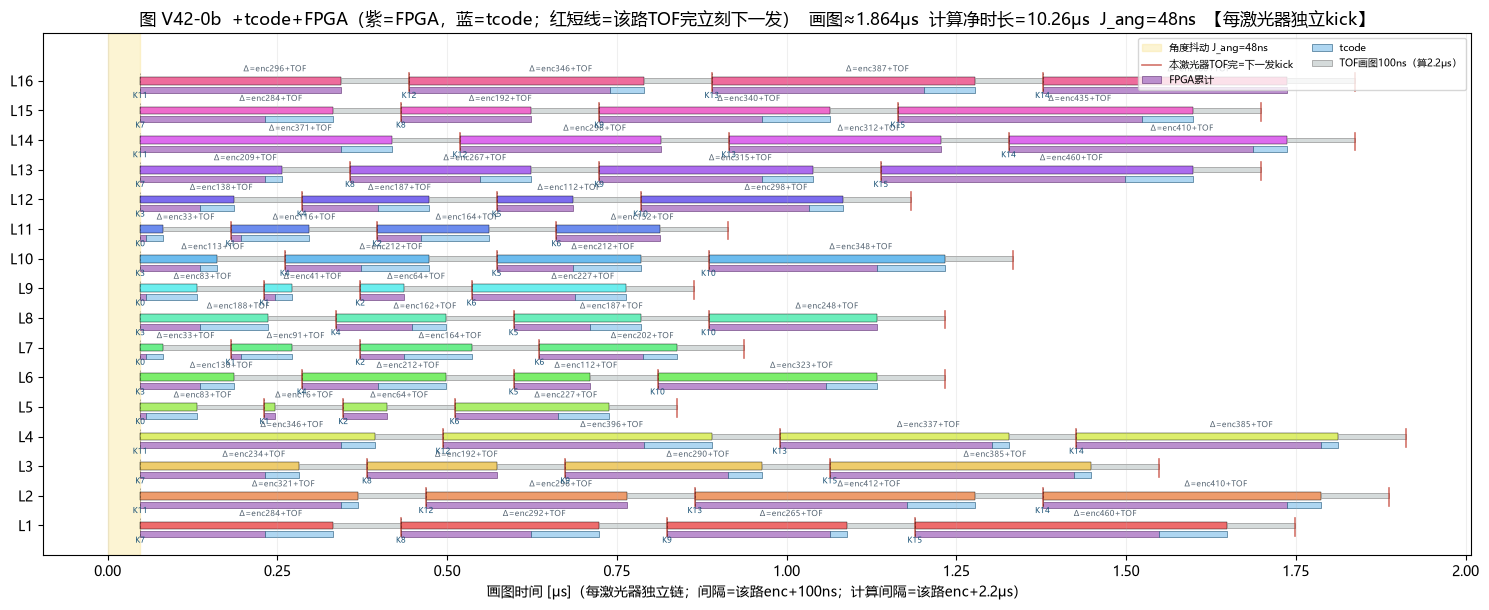

  J_ang=48ns；每激光器独立：间隔 = 该路(FPGA+tcode+delta) + TOF
  画图TOF=100ns；计算TOF_FIXED=2.2μs
  L1 kicks=[7, 8, 9, 15]
       enc(FPGA+tcode)=['284', '292', '265', '460']  FPGA部分=['184', '192', '240', '360']
       间隔ns(enc+TOF_calc)=['2484', '2492', '2465', '2660']
  L2 kicks=[11, 12, 13, 14]
       enc(FPGA+tcode)=['321', '296', '412', '410']  FPGA部分=['296', '296', '312', '360']
       间隔ns(enc+TOF_calc)=['2521', '2496', '2612', '2610']
  L3 kicks=[7, 8, 9, 15]
       enc(FPGA+tcode)=['234', '192', '290', '385']  FPGA部分=['184', '192', '240', '360']
       间隔ns(enc+TOF_calc)=['2434', '2392', '2490', '2585']
  L4 kicks=[11, 12, 13, 14]
       enc(FPGA+tcode)=['346', '396', '337', '385']  FPGA部分=['296', '296', '312', '360']
       间隔ns(enc+TOF_calc)=['2546', '2596', '2537', '2585']
  … 共 16 个激光器（上仅列前4路）
  计算净扫角时长(最慢那路墙钟) 10.26μs


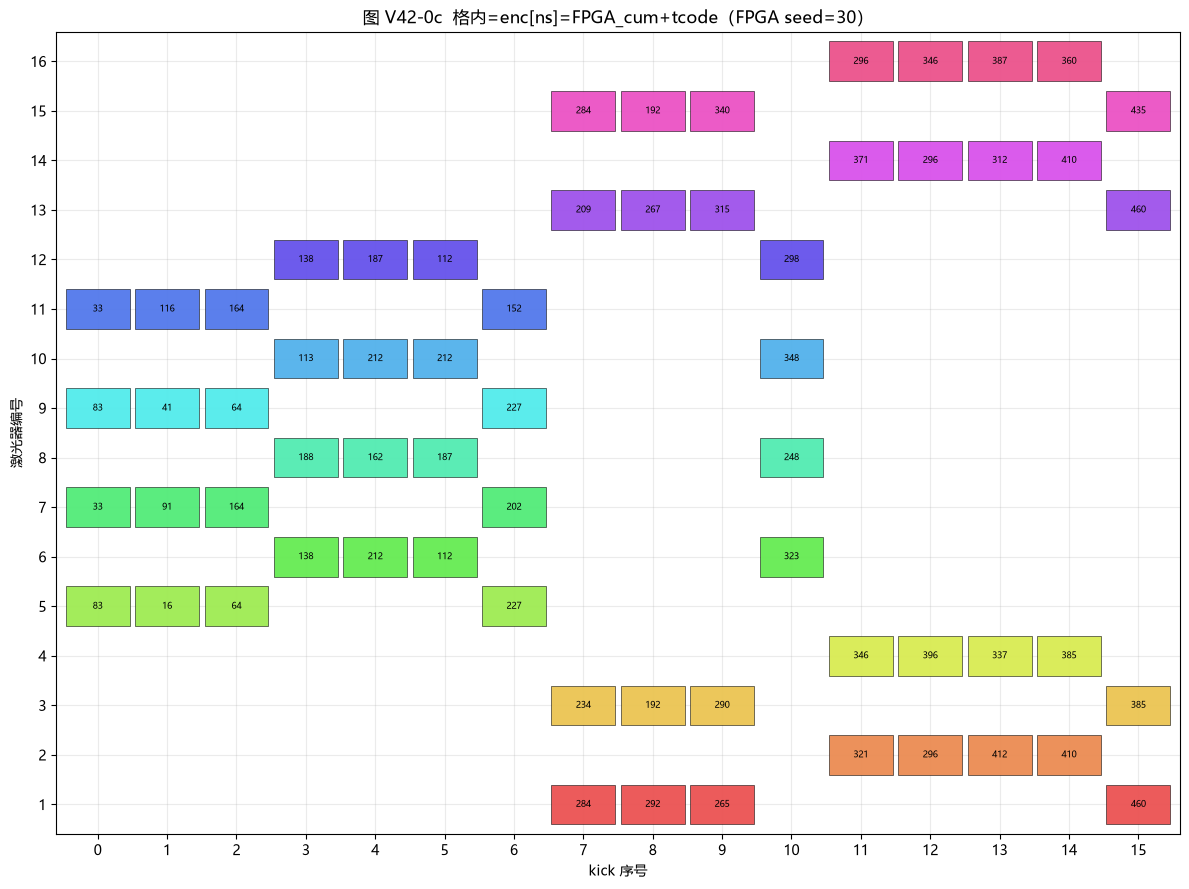

In [40]:
# ============================================================================
# 3c. 时序链演示（当前角度）—— 每激光器独立 kick 链
# ============================================================================
# 每激光器 L 自己的顺序：
#   T_kick → enc(=FPGA_cum + tcode + delta，相加) → t_fire → TOF → 立刻下一发
# 不同激光器不共用 kick、互不等待（不再跨激光器 max）。

# ---- 0：Excel 基线（无 tcode / 无 FPGA）----
_f0, _sch0 = build_kick_schedule(use_tcode=False, cum_encode_ns=None)
print(f"3c. J_ang={_sch0.get('angle_jitter_ns', 0):.0f}ns；"
      f"计算TOF={TIMING['tof_fixed_us']}μs；画图按{PLOT_TOF_NS:.0f}ns压缩；"
      f"independent_lasers={_sch0.get('independent_lasers')}")
plot_timing_timeline(
    _f0, _sch0,
    f"图 V42-0  Excel（每激光器独立链；无FPGA）")

# ---- 0b：tcode + FPGA（每路独立）----
_inc_demo, _cum_demo = make_fpga_cum(FPGA["seed_ours"])
_f1, _sch1 = build_kick_schedule(use_tcode=True, cum_encode_ns=_cum_demo)
print("3c-0b. enc=FPGA_cum+tcode（相加）；每激光器自己的 kick 时刻可不同")
print("  本角 FPGA 累计 [ns] kick0..15（shared_across_lasers="
      f"{FPGA['shared_across_lasers']}）:")
print("   " + " ".join(f"{_cum_demo[0, k]:5.0f}" for k in range(16)))
plot_timing_timeline(
    _f1, _sch1,
    f"图 V42-0b  +tcode+FPGA（紫=FPGA，蓝=tcode；红短线=该路TOF完立刻下一发）")

# ---- 0c：enc 栅格 ----
plot_kick_grid(
    lambda lid, k: f"{encode_delay_ns(lid, k, use_tcode=True, cum_ns=_cum_demo):.0f}",
    f"图 V42-0c  格内=enc[ns]=FPGA_cum+tcode（FPGA seed={FPGA['seed_ours']}）")


# 4.i  Excel 时序基线

不加 tcode / FPGA，只看鬼影与对射。


【i Excel + 对射】峰级统计
        类型     保留     丢弃
       纯真峰      0      0
       纯鬼峰      0     64
      纯对射峰     16      0
       混合峰     16      0


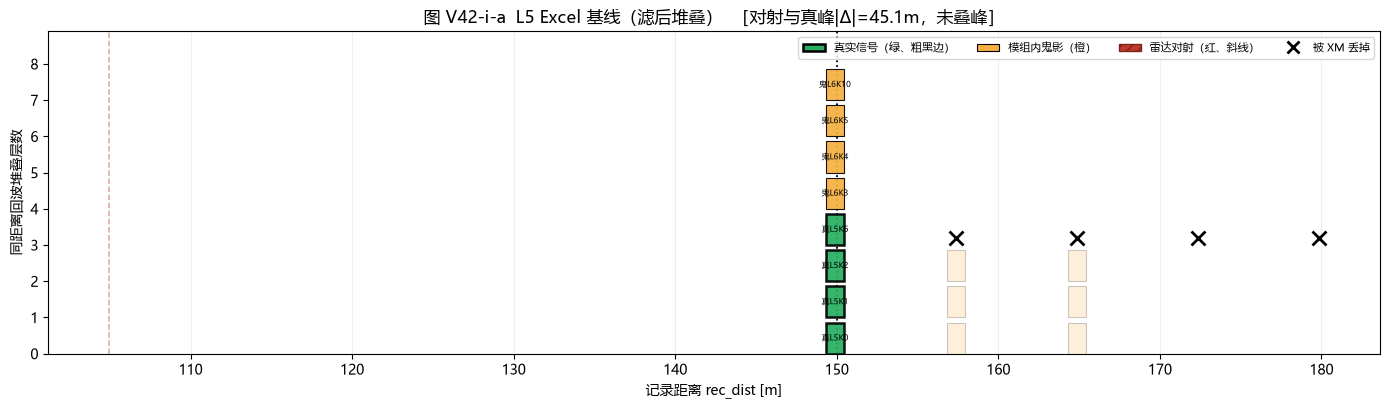

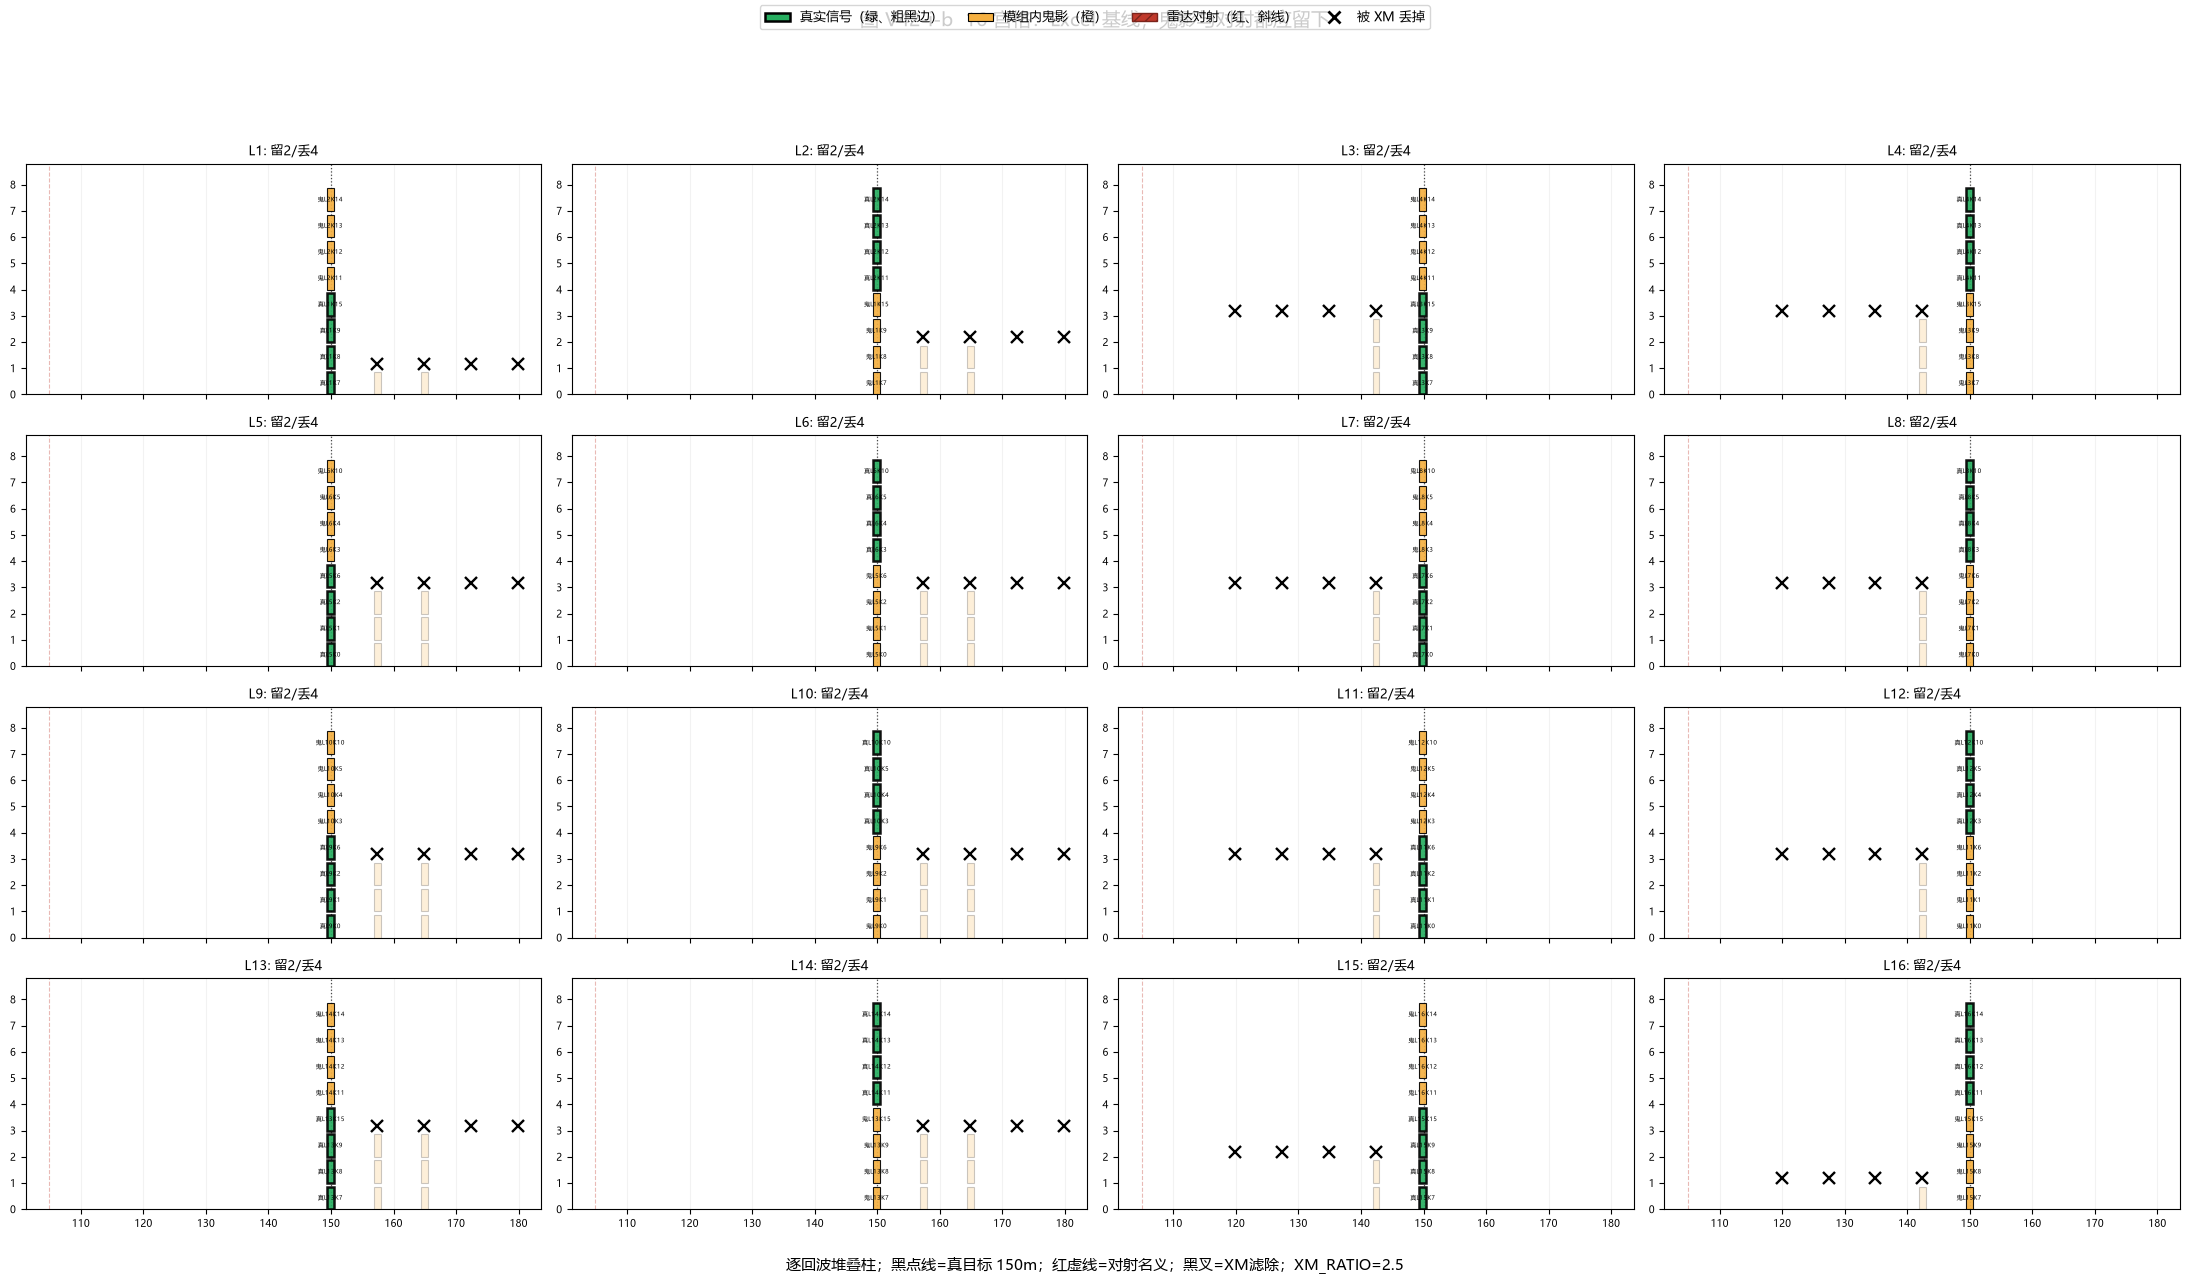

In [41]:
# ============================================================================
# 4.i  Excel 时序 + 对射/鬼影（基线）
# ============================================================================
S_i = run_scene(use_tcode=False, use_fpga=False)
stat_i = print_stats("i Excel + 对射", S_i["hs"], S_i["rs"])
plot_echo_channel(S_i["hs"], S_i["rs"], SCENE["demo_laser"],
                  f"图 V42-i-a  L{SCENE['demo_laser']} Excel 基线（滤后堆叠）",
                  S_i["D"])
plot_echo_grid(S_i["hs"], S_i["rs"],
               f"图 V42-i-b  16 宫格：Excel 基线，鬼影与对射都应留下",
               S_i["D"])


# 4.ii  加入 tcode

模组内鬼影应被打散并被 XM 丢掉；对射仍在。


【ii tcode(2.5) + 对射】峰级统计
        类型     保留     丢弃
       纯真峰      3      0
       纯鬼峰      9    102
      纯对射峰     16      0
       混合峰     11      2


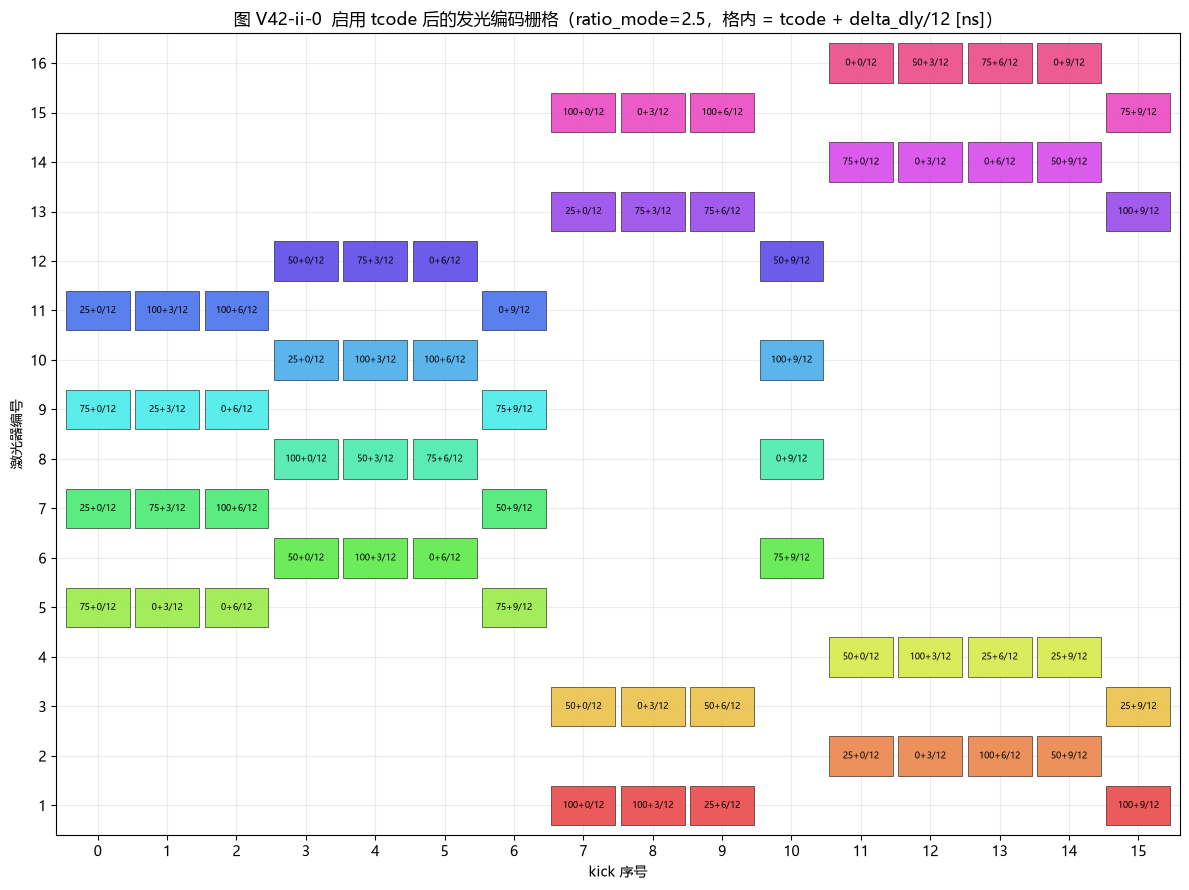

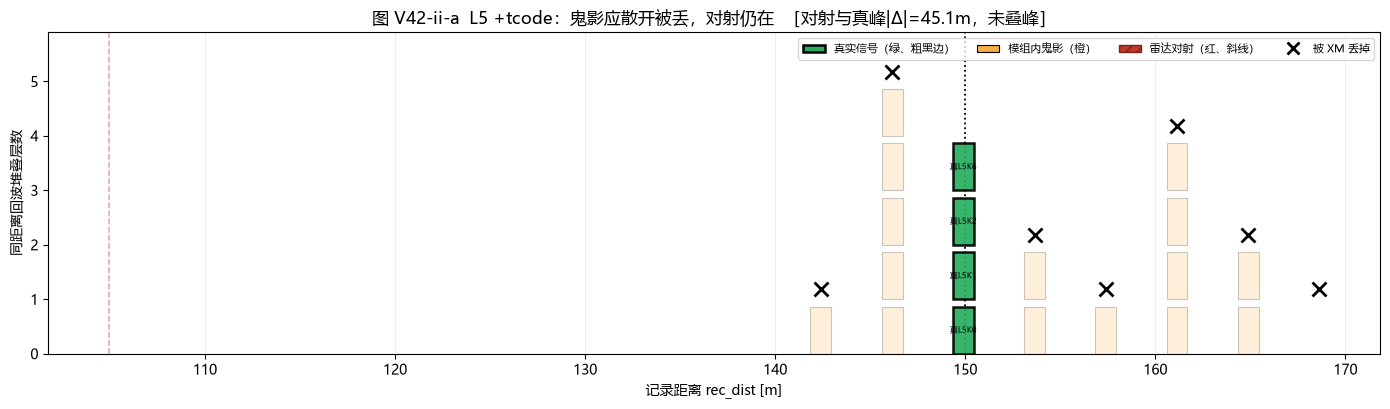

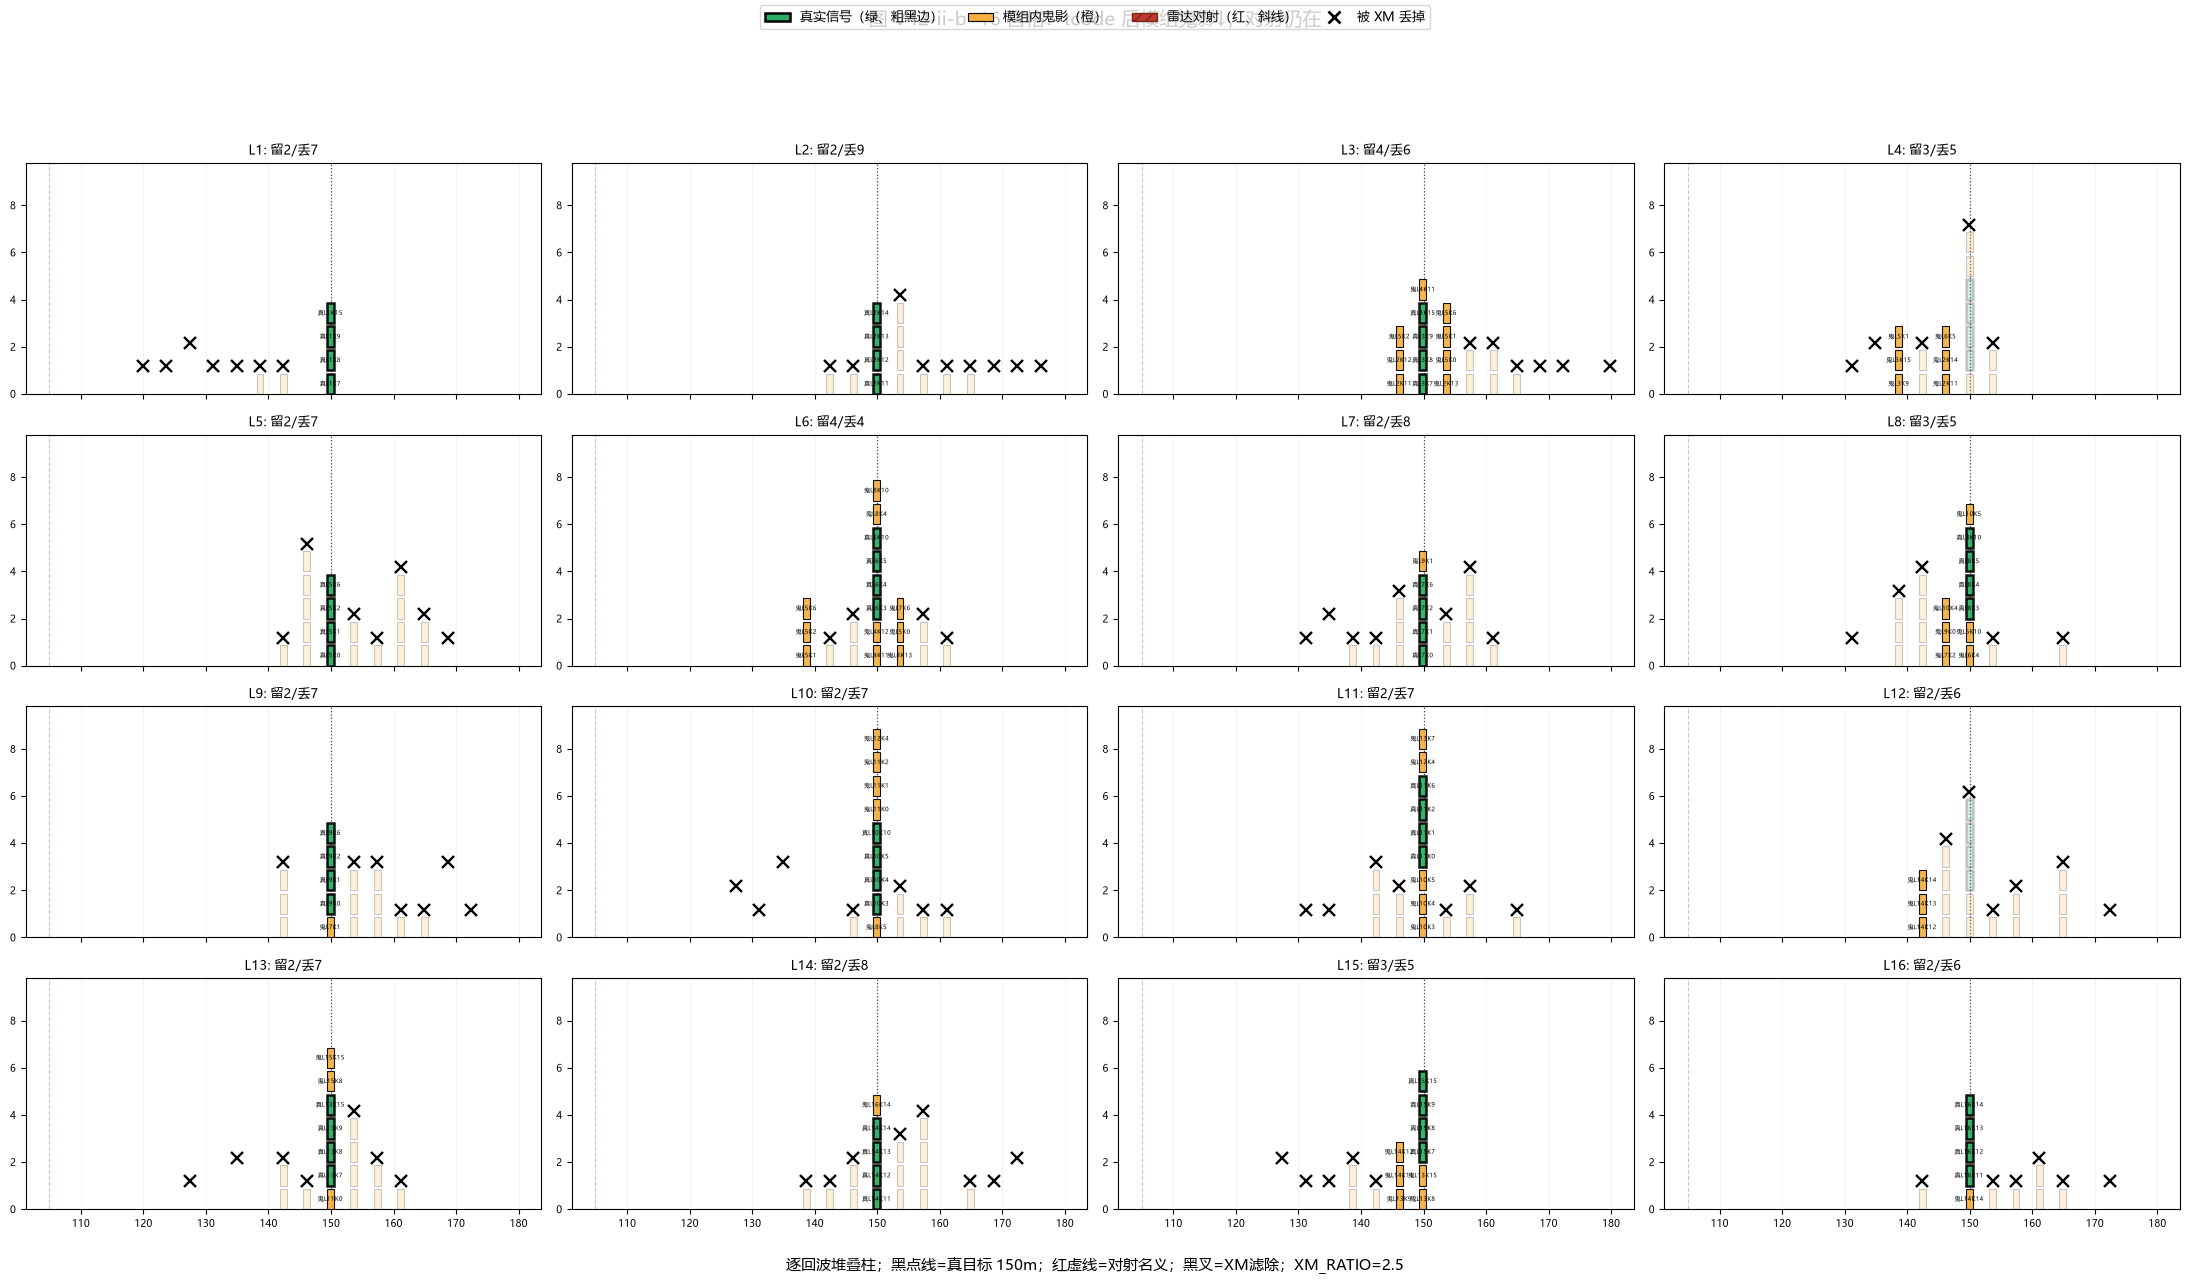

In [42]:
# ============================================================================
# 4.ii  + tcode
# ============================================================================
S_ii = run_scene(use_tcode=True, use_fpga=False)
stat_ii = print_stats(f"ii tcode({TCODE['ratio_mode']}) + 对射",
                      S_ii["hs"], S_ii["rs"])
plot_kick_grid(
    lambda lid, k: code_label(active_tx(lid, k, use_tcode=True), k),
    f"图 V42-ii-0  启用 tcode 后的发光编码栅格"
    f"（ratio_mode={TCODE['ratio_mode']}，格内 = tcode + delta_dly/12 [ns]）")
plot_echo_channel(S_ii["hs"], S_ii["rs"], SCENE["demo_laser"],
                  f"图 V42-ii-a  L{SCENE['demo_laser']} +tcode：鬼影应散开被丢，对射仍在",
                  S_ii["D"])
plot_echo_grid(S_ii["hs"], S_ii["rs"],
               f"图 V42-ii-b  16 宫格：tcode 后模组鬼影↓，对射仍在",
               S_ii["D"])


# 4.iii  加入双方 FPGA 累计抖动

最坏对射：同型号、同时序、同 tcode；**我方与对射雷达都有 FPGA**。
FPGA 抖动计入编码段；对射相对落点 $$(\phi + d_{\mathrm{radar}} - d_{\mathrm{ours}})\bmod T_{\mathrm{kick}}[k]$$（每 kick 周期可变）。


【iii tcode + 双方 FPGA + 对射】峰级统计
        类型     保留     丢弃
       纯真峰      6      0
       纯鬼峰      0    193
      纯对射峰      0     56
       混合峰     10      0


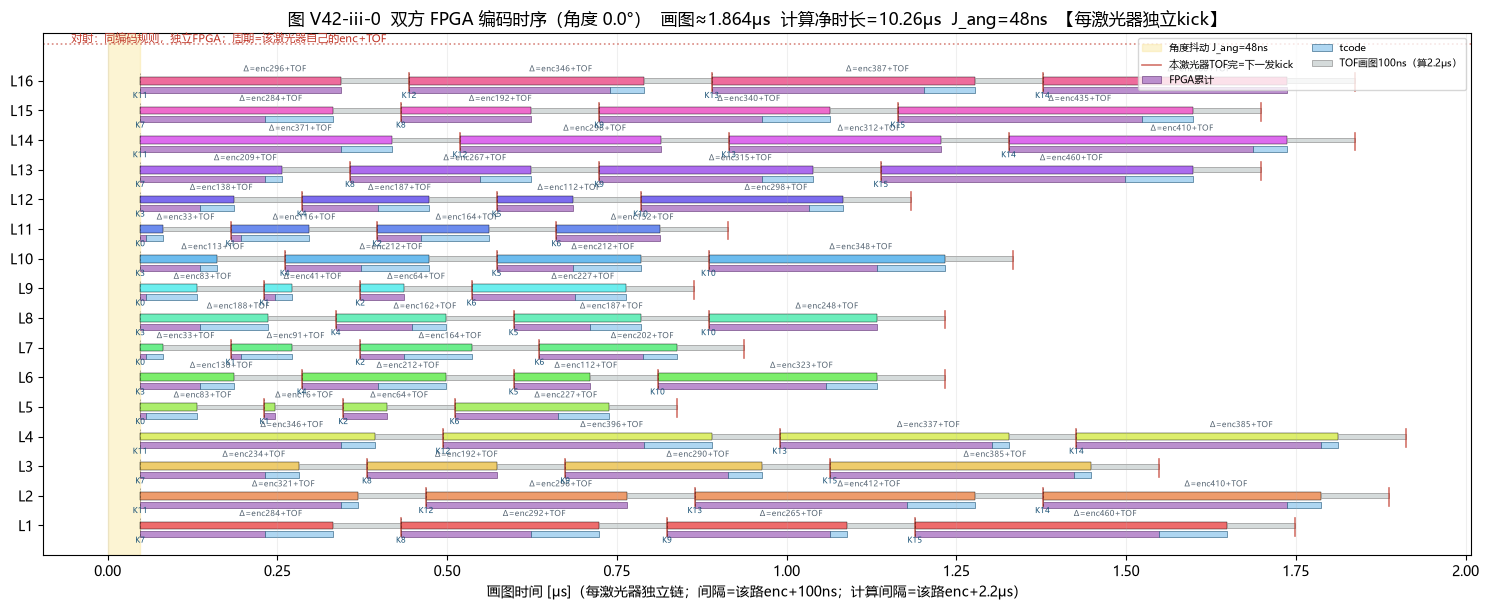

  J_ang=48ns；每激光器独立：间隔 = 该路(FPGA+tcode+delta) + TOF
  画图TOF=100ns；计算TOF_FIXED=2.2μs
  L1 kicks=[7, 8, 9, 15]
       enc(FPGA+tcode)=['284', '292', '265', '460']  FPGA部分=['184', '192', '240', '360']
       间隔ns(enc+TOF_calc)=['2484', '2492', '2465', '2660']
  L2 kicks=[11, 12, 13, 14]
       enc(FPGA+tcode)=['321', '296', '412', '410']  FPGA部分=['296', '296', '312', '360']
       间隔ns(enc+TOF_calc)=['2521', '2496', '2612', '2610']
  L3 kicks=[7, 8, 9, 15]
       enc(FPGA+tcode)=['234', '192', '290', '385']  FPGA部分=['184', '192', '240', '360']
       间隔ns(enc+TOF_calc)=['2434', '2392', '2490', '2585']
  L4 kicks=[11, 12, 13, 14]
       enc(FPGA+tcode)=['346', '396', '337', '385']  FPGA部分=['296', '296', '312', '360']
       间隔ns(enc+TOF_calc)=['2546', '2596', '2537', '2585']
  … 共 16 个激光器（上仅列前4路）
  计算净扫角时长(最慢那路墙钟) 10.26μs


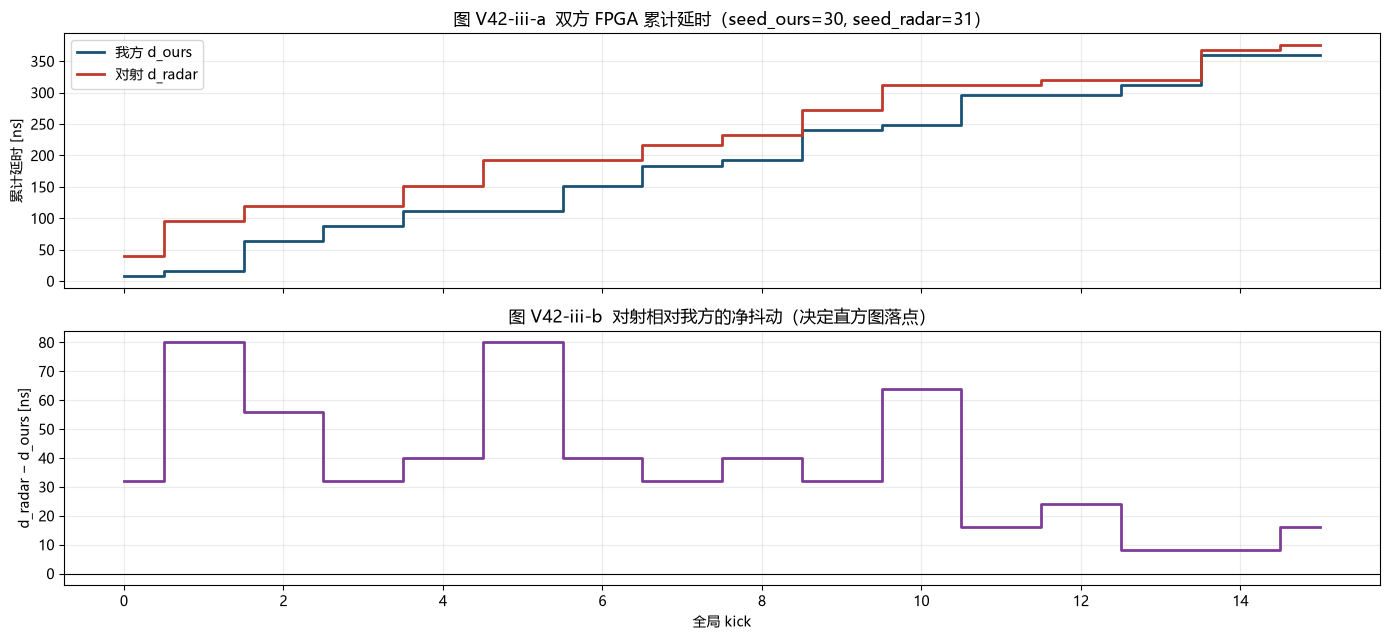

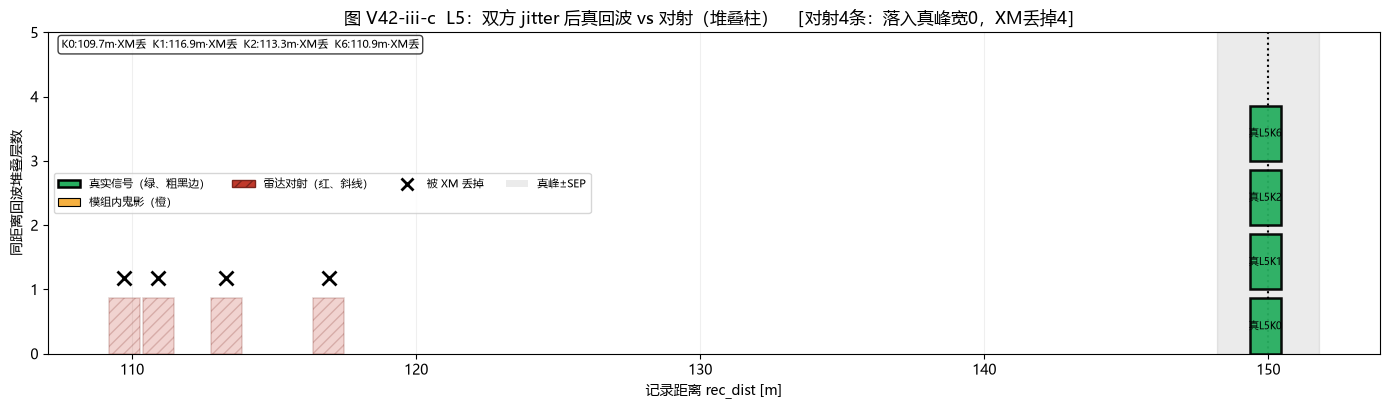

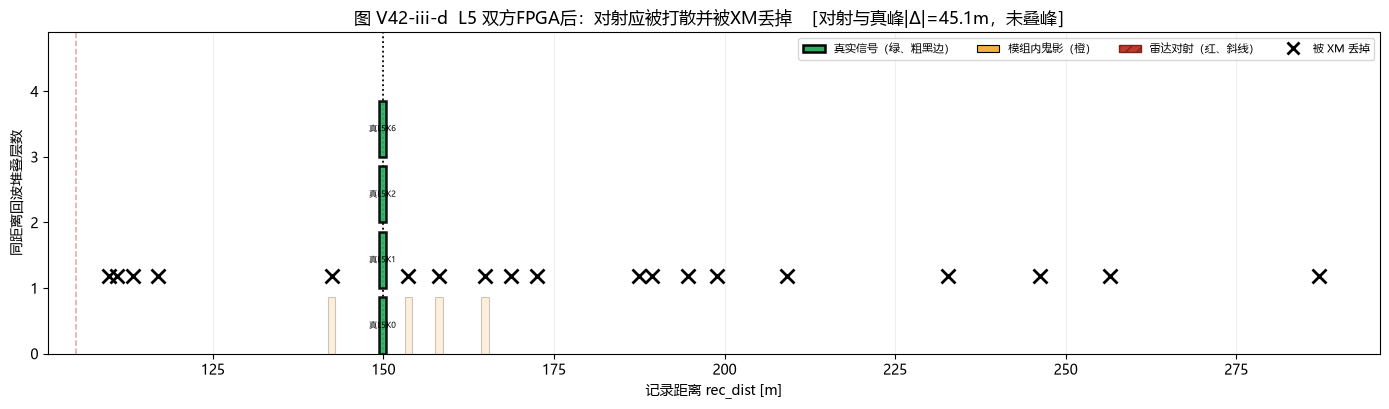

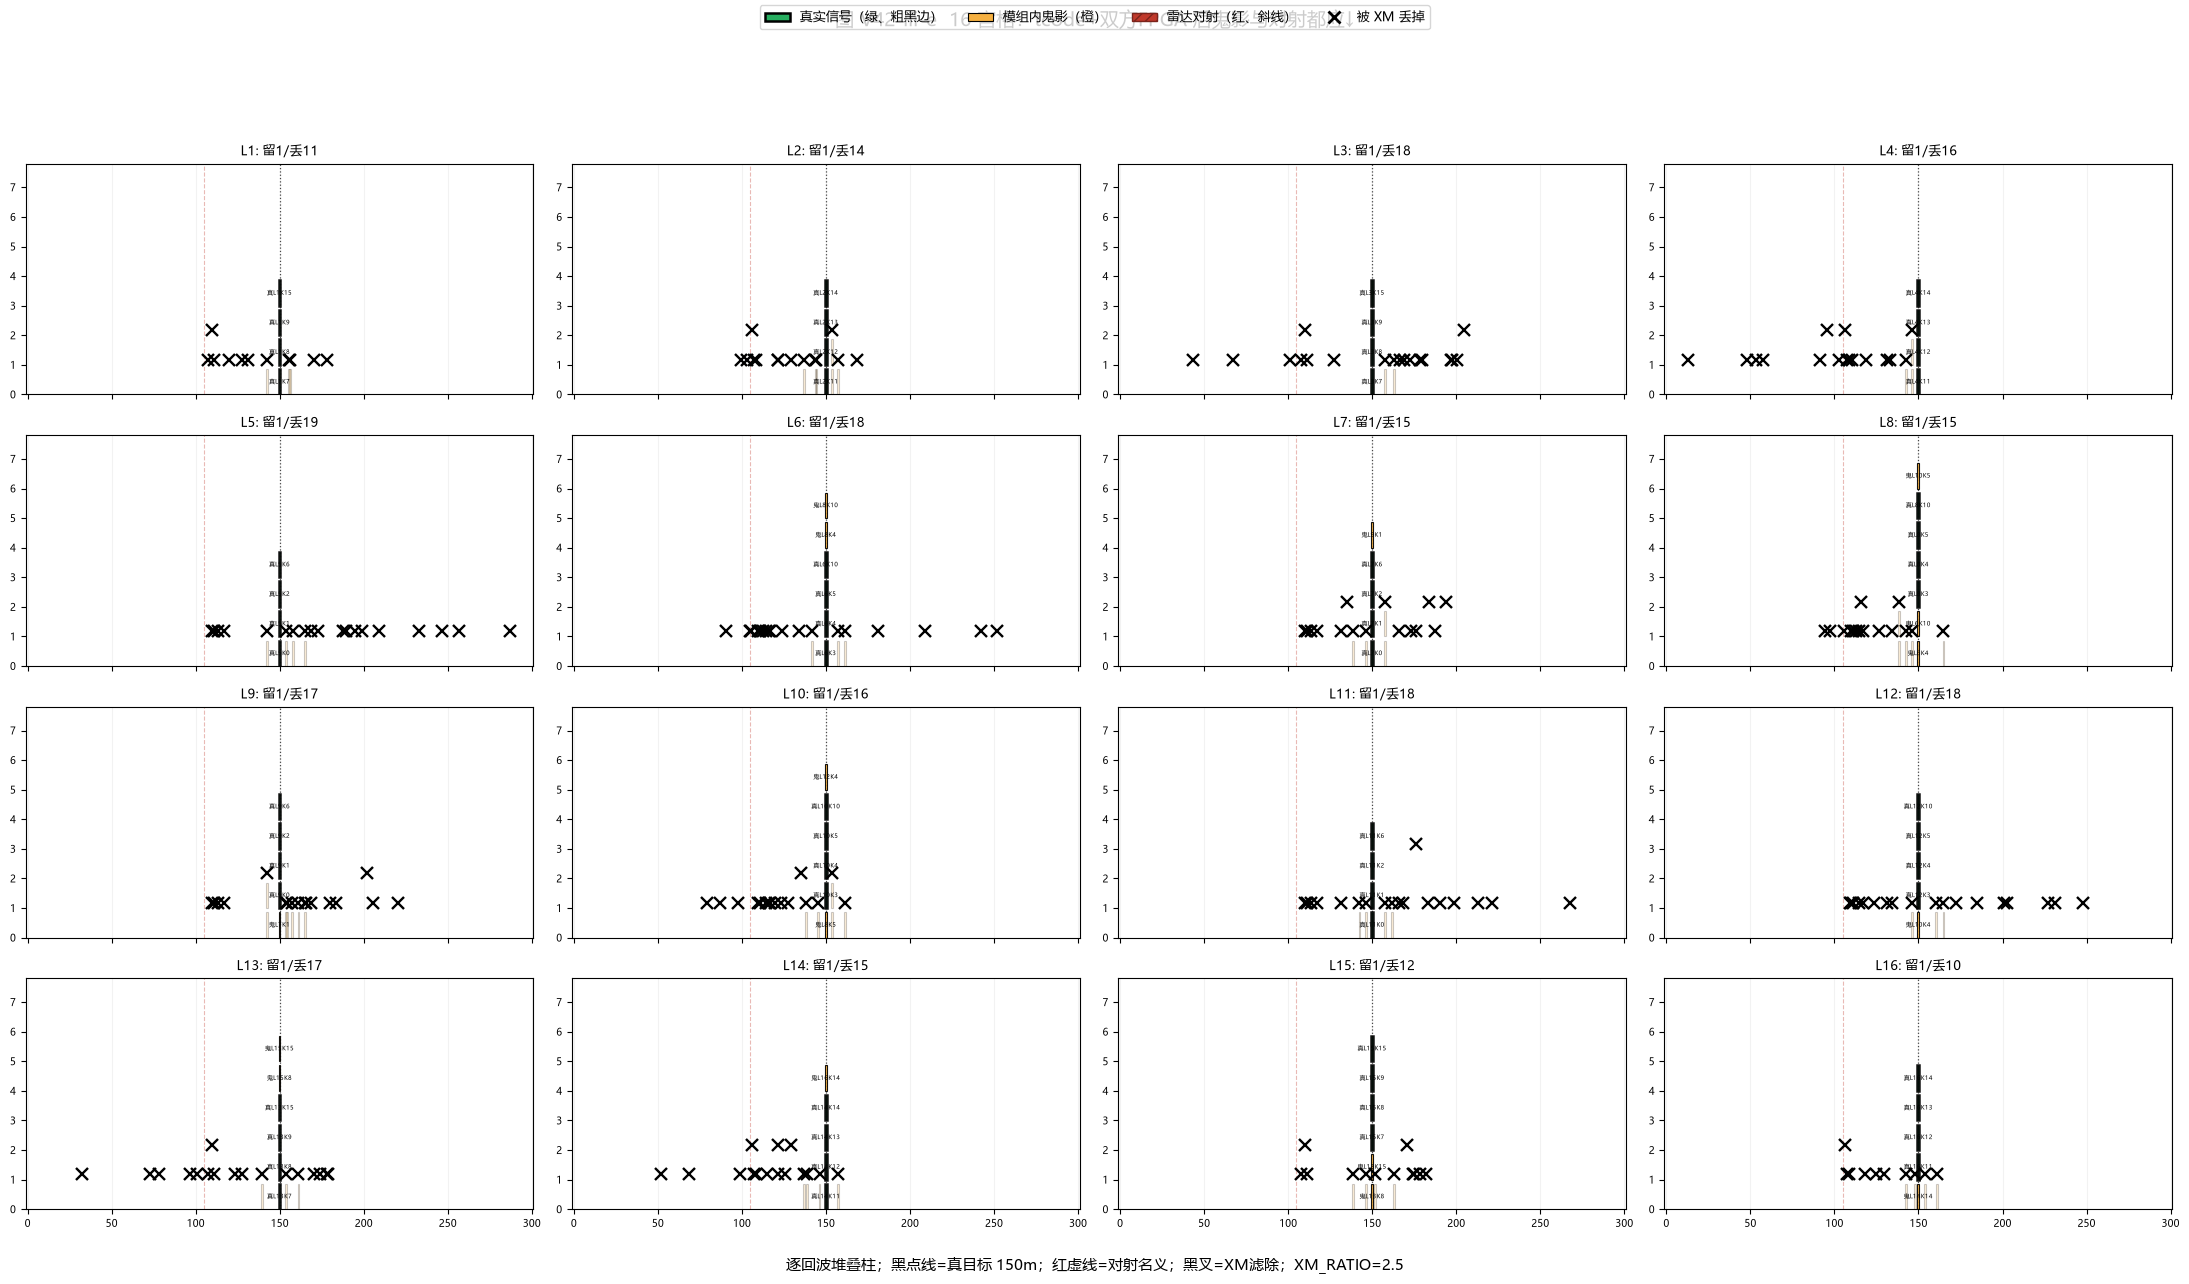

In [43]:
# ============================================================================
# 4.iii  + FPGA（我方 + 对射雷达双方累计抖动）
# ============================================================================
# 最坏设定：同型号 / 同时序 / 同 tcode；双方独立 FPGA 种子
assert RADAR["same_model"] and RADAR["same_timing"] and RADAR["same_tcode"]
S_iii = run_scene(use_tcode=True, use_fpga=True)
stat_iii = print_stats("iii tcode + 双方 FPGA + 对射", S_iii["hs"], S_iii["rs"])
plot_timing_timeline(
    S_iii["firings"], S_iii["schedule"],
    f"图 V42-iii-0  双方 FPGA 编码时序（角度 {TIMING['scan_angle_deg']}°）",
    cum_radar=S_iii["cum_radar"])

# 相对抖动轨迹
fig, axes = plt.subplots(2, 1, figsize=(14, 6.5), sharex=True)
axes[0].step(range(16), S_iii["cum_ours"][0], where="mid", lw=2.0,
             color="#1a5276", label="我方 d_ours")
axes[0].step(range(16), S_iii["cum_radar"][0], where="mid", lw=2.0,
             color=RADAR_COLOR, label="对射 d_radar")
axes[0].set_ylabel("累计延时 [ns]")
axes[0].set_title(f"图 V42-iii-a  双方 FPGA 累计延时"
                  f"（seed_ours={FPGA['seed_ours']}, seed_radar={FPGA['seed_radar']}）")
axes[0].legend(); axes[0].grid(alpha=0.25)
rel = S_iii["cum_radar"][0] - S_iii["cum_ours"][0]
axes[1].step(range(16), rel, where="mid", lw=2.0, color="#7d3c98")
axes[1].axhline(0, color="k", lw=0.8)
axes[1].set_xlabel("全局 kick")
axes[1].set_ylabel("d_radar − d_ours [ns]")
axes[1].set_title("图 V42-iii-b  对射相对我方的净抖动（决定直方图落点）")
axes[1].grid(alpha=0.25)
plt.tight_layout(); plt.show()

lid = SCENE["demo_laser"]
plot_true_radar_stack(
    S_iii["hs"], S_iii["rs"], lid,
    f"图 V42-iii-c  L{lid}：双方 jitter 后真回波 vs 对射（堆叠柱）",
    S_iii["D"])

plot_echo_channel(S_iii["hs"], S_iii["rs"], lid,
                  f"图 V42-iii-d  L{lid} 双方FPGA后：对射应被打散并被XM丢掉",
                  S_iii["D"])
plot_echo_grid(S_iii["hs"], S_iii["rs"],
               "图 V42-iii-e  16 宫格：tcode+双方FPGA 后鬼影与对射都应↓",
               S_iii["D"])


# 4.iv  加入一字滤波

左/中/右 = **三次独立的 iii 仿真**：tcode + 双方 FPGA + 对射均开启；
雷达参数（phase / same_*）不变，仅 FPGA 种子不同（中 = 步骤 iii 种子，左右见 `LINE.seed_*`）。

中间角度 XM 后保留的峰，若相对左右最近峰距离差都 > thr → 判角度孤立并丢掉。由此可检验对射残留是否因三次随机落点不一致而被一字清掉。


【iv-左 (seed_o=40, seed_r=41)】峰级统计
        类型     保留     丢弃
       纯真峰      6      0
       纯鬼峰      0    196
      纯对射峰      0     59
       混合峰     10      1

【iv-中 (seed_o=30, seed_r=31)】峰级统计
        类型     保留     丢弃
       纯真峰      6      0
       纯鬼峰      0    193
      纯对射峰      0     56
       混合峰     10      0

【iv-右 (seed_o=44, seed_r=45)】峰级统计
        类型     保留     丢弃
       纯真峰      6      0
       纯鬼峰      0    195
      纯对射峰      0     59
       混合峰     10      1

【iv 一字滤波】一字滤波 thr=3.0m
  真峰留下 16；对射留下 0 / 丢掉 0；鬼影留下 0


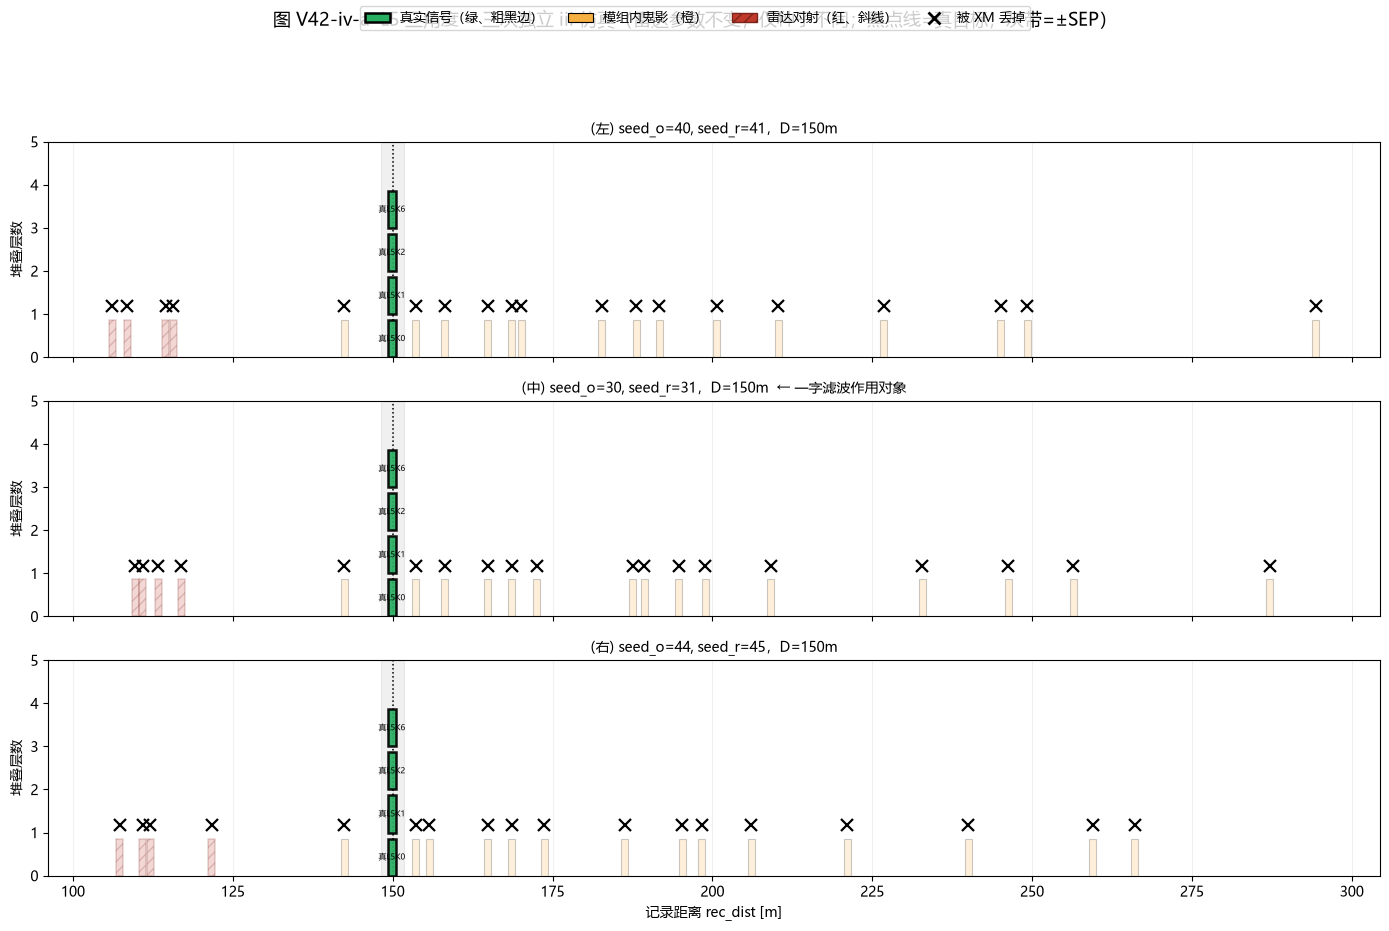

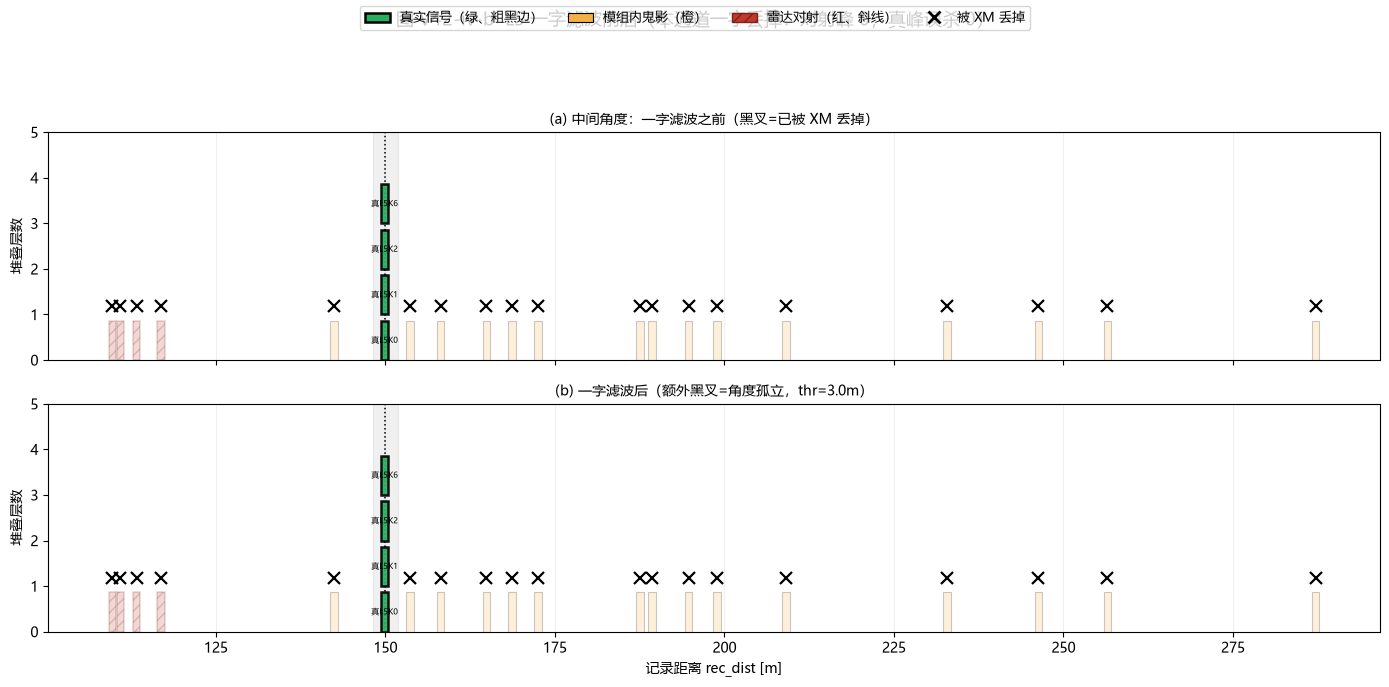


三角度种子：左(40/41) 中(30/31) 右(44/45)
雷达参数不变：phase=700.0ns，same_model/timing/tcode=True/True/True


In [44]:
# ============================================================================
# 4.iv  + 一字滤波（三角度 = 三次独立的 iii 仿真）
# ============================================================================
# 雷达参数不变（phase / same_*）；每次仿真换一对 FPGA 种子。
# 中间角度沿用步骤 iii 的种子，左右用 LINE 里另设的种子。

def run_iii_angle(D, seed_ours, seed_radar, tag):
    assert RADAR["enable"], "一字滤波要求雷达对射开启（与 iii 同配置）"
    out = run_scene(use_tcode=True, use_fpga=True, D=D,
                    seed_ours=seed_ours, seed_radar=seed_radar)
    c = print_stats(f"iv-{tag} (seed_o={seed_ours}, seed_r={seed_radar})",
                    out["hs"], out["rs"])
    out["stat"] = c
    return out


A_L = run_iii_angle(SCENE["line_D_left_m"],
                    LINE["seed_ours_left"], LINE["seed_radar_left"], "左")
A_M = run_iii_angle(SCENE["line_D_mid_m"],
                    FPGA["seed_ours"], FPGA["seed_radar"], "中")
A_R = run_iii_angle(SCENE["line_D_right_m"],
                    LINE["seed_ours_right"], LINE["seed_radar_right"], "右")

line_iv = line_filter_all(A_L["rs"], A_M["rs"], A_R["rs"])
stat_iv = summarize_line("iv 一字滤波", line_iv, A_M["hs"])

lid = SCENE["demo_laser"]
sep_m = TCODE["sep_ns"] * NS * C_LIGHT / 2.0


def _stack_on_ax(ax, ang, title, line_res=None):
    """在给定 ax 上画逐回波堆叠柱；若给 line_res，则黑叉标一字丢掉。"""
    h, rr = ang["hs"][lid], ang["rs"][lid]
    b_lo, b_hi = occupied_range({lid: h}, pad=25)
    ymax = 1
    for b in range(b_lo, b_hi + 1):
        q = peak_for_bin(rr, b)
        xm_drop = bool(q and q["is_xtalk"])
        for level, rec in enumerate(h["src"].get(b, [])):
            xc = b * HIST_BIN_M
            st = rec_style(rec, alpha=0.20 if xm_drop else 0.92)
            ax.add_patch(plt.Rectangle(
                (xc - 0.55, level), 1.1, 0.86, zorder=3, **st))
            if not xm_drop:
                ax.text(xc, level + 0.43, rec_label(rec),
                        ha="center", va="center", fontsize=5.5, zorder=4)
            ymax = max(ymax, level + 1)
    # XM 丢掉
    for q in rr["peaks"]:
        if q["is_xtalk"]:
            ax.plot(q["dist"], q["add"] + 0.18, "kx", ms=8, mew=1.6, zorder=6)
    # 一字丢掉（仅中间）
    if line_res is not None:
        for q in line_res[lid]["peaks"]:
            if q["is_line_ghost"]:
                ax.plot(q["dist"], max(q["add"], 0.3) + 0.35, "kx",
                        ms=11, mew=2.2, zorder=7)
    ax.axvline(ang["D"], color="k", ls=":", lw=1.1)
    ax.axvspan(ang["D"] - sep_m, ang["D"] + sep_m, color="k", alpha=0.06)
    ax.set_ylim(0, ymax + 1.0)
    ax.set_title(title, fontsize=10)
    ax.grid(alpha=0.18, axis="x")
    return b_lo, b_hi


# ---- 图 iv-a：三角度各自是一次完整 iii（堆叠柱）----
fig, axes = plt.subplots(3, 1, figsize=(14, 9.5), sharex=True)
_stack_on_ax(axes[0], A_L,
             f"(左) seed_o={A_L['seed_ours']}, seed_r={A_L['seed_radar']}，"
             f"D={A_L['D']:.0f}m")
_stack_on_ax(axes[1], A_M,
             f"(中) seed_o={A_M['seed_ours']}, seed_r={A_M['seed_radar']}，"
             f"D={A_M['D']:.0f}m  ← 一字滤波作用对象")
_stack_on_ax(axes[2], A_R,
             f"(右) seed_o={A_R['seed_ours']}, seed_r={A_R['seed_radar']}，"
             f"D={A_R['D']:.0f}m")
axes[2].set_xlabel("记录距离 rec_dist [m]")
for ax in axes:
    ax.set_ylabel("堆叠层数")
fig.legend(handles=type_legend(), loc="upper center", ncol=4, fontsize=9)
fig.suptitle(f"图 V42-iv-a  L{lid} 三角度 = 三次独立 iii 仿真"
             f"（雷达参数不变，仅种子不同；黑点线=真目标，灰带=±SEP）",
             fontsize=13, y=0.995)
plt.tight_layout(rect=[0, 0.02, 1, 0.93]); plt.show()

# ---- 图 iv-b：中间角度 XM 后 vs 一字后（堆叠柱 + 黑叉）----
fig, axes = plt.subplots(2, 1, figsize=(14, 7.0), sharex=True)
_stack_on_ax(axes[0], A_M,
             "(a) 中间角度：一字滤波之前（黑叉=已被 XM 丢掉）")
_stack_on_ax(axes[1], A_M,
             f"(b) 一字滤波后（额外黑叉=角度孤立，thr={LINE['thr_m']:.1f}m）",
             line_res=line_iv)
axes[1].set_xlabel("记录距离 rec_dist [m]")
for ax in axes:
    ax.set_ylabel("堆叠层数")
# 标出一字丢掉的对射/真峰
n_radar_line_drop = 0
n_true_line_drop = 0
for q in line_iv[lid]["peaks"]:
    if not q["is_line_ghost"]:
        continue
    recs = [r for b in range(q["s"], q["e"] + 1)
            for r in A_M["hs"][lid]["src"].get(b, [])]
    if any(r.get("is_radar") for r in recs):
        n_radar_line_drop += 1
    if any(r.get("is_true") for r in recs):
        n_true_line_drop += 1
fig.legend(handles=type_legend(), loc="upper center", ncol=4, fontsize=9)
fig.suptitle(f"图 V42-iv-b  L{lid} 一字滤波前后"
             f"（本通道一字丢掉：对射峰 {n_radar_line_drop}，真峰误杀 {n_true_line_drop}）",
             fontsize=13, y=0.995)
plt.tight_layout(rect=[0, 0.02, 1, 0.92]); plt.show()

print(f"\n三角度种子：左({A_L['seed_ours']}/{A_L['seed_radar']}) "
      f"中({A_M['seed_ours']}/{A_M['seed_radar']}) "
      f"右({A_R['seed_ours']}/{A_R['seed_radar']})")
print(f"雷达参数不变：phase={RADAR['phase_ns']}ns，"
      f"same_model/timing/tcode="
      f"{RADAR['same_model']}/{RADAR['same_timing']}/{RADAR['same_tcode']}")


四步对比（D=150m，XM_RATIO=2.5，tcode.consider_gap=True，XM.use_pulse_width=False）
  步骤                        真保留    鬼保留    鬼丢掉     对射保留     对射丢掉
  ----------------------------------------------------------------------
  i Excel                     0      0     64       16        0
  ii tcode(2.5)               3      9    102       16        0
  iii +双方FPGA                 6      0    193        0       56
  iv 一字滤波                真留=16  对射留/丢=0/0  鬼留=0


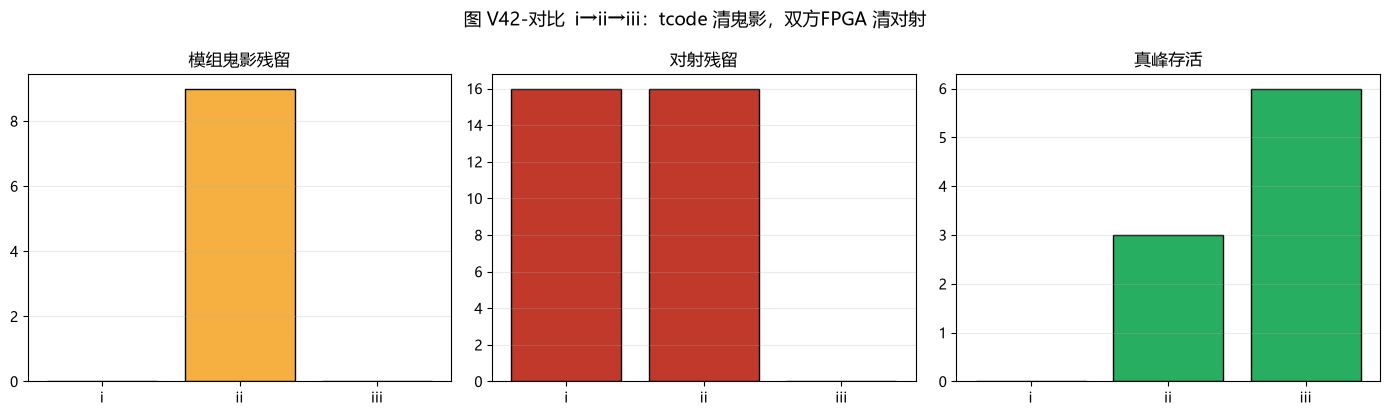

In [45]:
# ============================================================================
# 5. 四步对比
# ============================================================================
rows = [
    ("i Excel", stat_i),
    (f"ii tcode({TCODE['ratio_mode']})", stat_ii),
    ("iii +双方FPGA", stat_iii),
]
print("=" * 88)
print(f"四步对比（D={SCENE['demo_D_m']:.0f}m，XM_RATIO={XM['ratio']}，"
      f"tcode.consider_gap={TCODE['consider_gap']}，"
      f"XM.use_pulse_width={XM['use_pulse_width']}）")
print("=" * 88)
print(f"  {'步骤':<22} {'真保留':>6} {'鬼保留':>6} {'鬼丢掉':>6} "
      f"{'对射保留':>8} {'对射丢掉':>8}")
print("  " + "-" * 70)
for name, c in rows:
    print(f"  {name:<22} {c[('纯真峰','保留')]:>6d} "
          f"{c[('纯鬼峰','保留')]:>6d} {c[('纯鬼峰','丢弃')]:>6d} "
          f"{c[('纯对射峰','保留')]:>8d} {c[('纯对射峰','丢弃')]:>8d}")
print(f"  {'iv 一字滤波':<22} 真留={stat_iv['true_keep']}  "
      f"对射留/丢={stat_iv['fake_keep']}/{stat_iv['fake_drop']}  "
      f"鬼留={stat_iv['ghost_keep']}")

fig, axes = plt.subplots(1, 3, figsize=(14, 4.2))
labels = ["i", "ii", "iii"]
axes[0].bar(labels, [c[("纯鬼峰", "保留")] for _, c in rows],
            color=GHOST_COLOR, edgecolor="k")
axes[0].set_title("模组鬼影残留")
axes[1].bar(labels, [c[("纯对射峰", "保留")] for _, c in rows],
            color=RADAR_COLOR, edgecolor="k")
axes[1].set_title("对射残留")
axes[2].bar(labels, [c[("纯真峰", "保留")] for _, c in rows],
            color=TRUE_COLOR, edgecolor="k")
axes[2].set_title("真峰存活")
for ax in axes:
    ax.grid(alpha=0.25, axis="y")
plt.suptitle("图 V42-对比  i→ii→iii：tcode 清鬼影，双方FPGA 清对射", fontsize=13)
plt.tight_layout(); plt.show()


In [46]:
# ============================================================================
# 6. 总结
# ============================================================================
print("=" * 78)
print("crosstalk_sim_v41 总结")
print("=" * 78)
print(f"""
【v41 时序】
  TIMING.tof_fixed_us     = {{TIMING['tof_fixed_us']}}μs（固定 TOF 段）
  TIMING.tof_window_ns    = {{TIMING['tof_window_ns']}}ns
  编码 enc                = FPGA + tcode + delta_dly/12（kick 后、发光前）
  kick 间隔               = max(enc) + tof_fixed（不固定）
  扫角总时长/预算         = 见 plot_timing_timeline 输出
  对射                    = 同编码表/同时序链，独立 FPGA

【参数开关】
  tcode.budget_ns       = {active_budget()}ns
  当前字母表            = {active_alphabet()}（{len(active_alphabet())} 档）
  tcode.consider_gap    = {TCODE['consider_gap']}（阈值 {TCODE['max_gap']}）
  XM.ratio              = {XM['ratio']}；TCODE.ratio_mode = {TCODE['ratio_mode']}
  XM.use_pulse_width    = {XM['use_pulse_width']}（本版关=δ回波）
  能量波形模型          : h(t;E)=N∞(1-exp(-E·s(t)))

【离散字母表结论】
  ratio=2.5：5 档 / 100ns 可零残留
  ratio=1.5：17 档 / 100ns 可零残留（5~15 档采样最好残留=1）
  不能要求「全串扰在真峰前」或「全进 ToF 前 200ns」

【四步】
  i   Excel → 鬼影+对射都稳
  ii  +离散tcode → 鬼影应清零，对射仍在
  iii +双方FPGA → 对射相对抖动
  iv  +一字滤波 → 三角度独立 iii 清对射孤点
""")


crosstalk_sim_v41 总结

【v41 时序】
  TIMING.tof_fixed_us     = {TIMING['tof_fixed_us']}μs（固定 TOF 段）
  TIMING.tof_window_ns    = {TIMING['tof_window_ns']}ns
  编码 enc                = FPGA + tcode + delta_dly/12（kick 后、发光前）
  kick 间隔               = max(enc) + tof_fixed（不固定）
  扫角总时长/预算         = 见 plot_timing_timeline 输出
  对射                    = 同编码表/同时序链，独立 FPGA

【参数开关】
  tcode.budget_ns       = 100ns
  当前字母表            = [0, 25, 50, 75, 100]（5 档）
  tcode.consider_gap    = True（阈值 2）
  XM.ratio              = 2.5；TCODE.ratio_mode = 2.5
  XM.use_pulse_width    = False（本版关=δ回波）
  能量波形模型          : h(t;E)=N∞(1-exp(-E·s(t)))

【离散字母表结论】
  ratio=2.5：5 档 / 100ns 可零残留
  ratio=1.5：17 档 / 100ns 可零残留（5~15 档采样最好残留=1）
  不能要求「全串扰在真峰前」或「全进 ToF 前 200ns」

【四步】
  i   Excel → 鬼影+对射都稳
  ii  +离散tcode → 鬼影应清零，对射仍在
  iii +双方FPGA → 对射相对抖动
  iv  +一字滤波 → 三角度独立 iii 清对射孤点



# 5. `consider_gap=False` 还能找到编码吗？

`crosstalk_negligible`：

- `consider_gap=True`：仅 $|L_e-L_r| > \max\_gap$ 的鬼影标可忽略（默认不进直方图）
- `consider_gap=False`：全部返回不可忽略 → **所有激光器对**都要靠 tcode 打散

下方用同一套「随机指派字母表 + XM 残留率」在 True/False 下各搜若干次，看零残留是否仍可达。


In [47]:
# ============================================================================
# 5. consider_gap=True vs False：编码可搜索性
# ============================================================================

def make_alphabet(n_levels, step_ns):
    """N 档、步长 step → [0, step, ..., step*(N-1)]"""
    return [int(step_ns * i) for i in range(int(n_levels))]


def random_tcode_table(alphabet, rng):
    """给每个 (laser, kick) 从字母表随机指派。"""
    table = {}
    for lid in laser_ids:
        for k in SHOT_KICKS[lid]:
            table[(lid, k)] = int(rng.choice(alphabet))
    return table


def noise_stats_from_scene(S):
    """噪点率：XM 后仍保留的非真峰 / 全部非真峰；另回报真峰保留数、净扫角时间。"""
    hs, rs = S["hs"], S["rs"]
    n_true_keep = n_nont_keep = n_nont_drop = 0
    for lid, rr in rs.items():
        for q in rr["peaks"]:
            recs = [r for b in range(q["s"], q["e"] + 1)
                    for r in hs[lid]["src"].get(b, [])]
            n_true = sum(1 for r in recs if r.get("is_true"))
            n_radar = sum(1 for r in recs if r.get("is_radar"))
            n_ghost = len(recs) - n_true - n_radar
            pure_true = n_true > 0 and n_radar == 0 and n_ghost == 0
            if pure_true:
                if not q["is_xtalk"]:
                    n_true_keep += 1
            else:
                if q["is_xtalk"]:
                    n_nont_drop += 1
                else:
                    n_nont_keep += 1
    n_nont = n_nont_keep + n_nont_drop
    noise_rate = n_nont_keep / max(n_nont, 1)
    return {
        "noise_rate": noise_rate,
        "true_keep": n_true_keep,
        "nont_keep": n_nont_keep,
        "nont_drop": n_nont_drop,
        "net_scan_us": S["schedule"].get("net_scan_us", S["schedule"]["total_scan_us"]),
        "angle_jitter_ns": S["schedule"].get("angle_jitter_ns", 0.0),
    }


def eval_table(table, consider_gap, n_trials=3, use_fpga=False, seed0=0):
    """临时切换码表与 consider_gap，跑若干蒙卡，返回平均噪点率。"""
    old_gap = TCODE["consider_gap"]
    old_mode = TCODE["ratio_mode"]
    global TCODE_R25
    old_tbl = dict(TCODE_R25)
    TCODE["consider_gap"] = consider_gap
    TCODE["ratio_mode"] = "2.5"
    TCODE_R25.clear()
    TCODE_R25.update(table)
    rates, times, true_keeps = [], [], []
    try:
        for t in range(n_trials):
            S = run_scene(use_tcode=True, use_fpga=use_fpga,
                          seed_ours=FPGA["seed_ours"] + t,
                          seed_radar=FPGA["seed_radar"] + t,
                          angle_deg=float(t))
            st = noise_stats_from_scene(S)
            rates.append(st["noise_rate"])
            times.append(st["net_scan_us"])
            true_keeps.append(st["true_keep"])
    finally:
        TCODE["consider_gap"] = old_gap
        TCODE["ratio_mode"] = old_mode
        TCODE_R25.clear()
        TCODE_R25.update(old_tbl)
    return {
        "noise_rate": float(np.mean(rates)),
        "noise_std": float(np.std(rates)),
        "net_scan_us": float(np.mean(times)),
        "true_keep": float(np.mean(true_keeps)),
        "zero_noise": all(r < 1e-12 for r in rates),
    }


def search_gap_compare(alphabet, n_samples=40, n_trials=2, seed=7):
    rng = np.random.default_rng(seed)
    rows = []
    for gap_flag in (True, False):
        best = None
        n_zero = 0
        for i in range(n_samples):
            tbl = random_tcode_table(alphabet, rng)
            ev = eval_table(tbl, consider_gap=gap_flag, n_trials=n_trials,
                            use_fpga=False, seed0=i)
            if ev["zero_noise"]:
                n_zero += 1
            if best is None or (ev["noise_rate"], ev["net_scan_us"]) < (
                    best["noise_rate"], best["net_scan_us"]):
                best = dict(ev)
                best["table"] = tbl
                best["sample"] = i
        rows.append((gap_flag, n_zero, n_samples, best))
        print(f"consider_gap={gap_flag}: 零噪点 {n_zero}/{n_samples}；"
              f"最优噪点率={best['noise_rate']:.3f}±{best['noise_std']:.3f}，"
              f"净时长={best['net_scan_us']:.2f}μs，真峰留={best['true_keep']:.1f}")
    return rows


print("5. consider_gap 对比搜索（默认字母表 + 16ns×N 字母表）")
print("-" * 60)
_alph_default = list(active_alphabet())
print(f"A) 当前字母表 { _alph_default }（{len(_alph_default)} 档）")
_rows_A = search_gap_compare(_alph_default, n_samples=30, n_trials=2, seed=11)

_alph_16x5 = make_alphabet(5, 16)
print(f"\nB) 16ns×5 档字母表 { _alph_16x5 }")
_rows_B = search_gap_compare(_alph_16x5, n_samples=30, n_trials=2, seed=13)

_alph_16x8 = make_alphabet(8, 16)
print(f"\nC) 16ns×8 档字母表 { _alph_16x8 }")
_rows_C = search_gap_compare(_alph_16x8, n_samples=30, n_trials=2, seed=17)

print("\n结论：")
print("  · consider_gap=False 时约束更严，同一字母表零残留更难；")
print("  · 加大 N（更多 16ns 档）通常能找回可接受的噪点率；")
print("  · 不是『找不到』，而是『同样档数下更难 / 需要更大编码跨度』。")


5. consider_gap 对比搜索（默认字母表 + 16ns×N 字母表）
------------------------------------------------------------
A) 当前字母表 [0, 25, 50, 75, 100]（5 档）
consider_gap=True: 零噪点 0/30；最优噪点率=0.238±0.000，净时长=9.15μs，真峰留=2.0
consider_gap=False: 零噪点 0/30；最优噪点率=0.203±0.000，净时长=9.17μs，真峰留=0.0

B) 16ns×5 档字母表 [0, 16, 32, 48, 64]
consider_gap=True: 零噪点 0/30；最优噪点率=0.229±0.000，净时长=8.99μs，真峰留=4.0
consider_gap=False: 零噪点 0/30；最优噪点率=0.195±0.000，净时长=9.04μs，真峰留=0.0

C) 16ns×8 档字母表 [0, 16, 32, 48, 64, 80, 96, 112]
consider_gap=True: 零噪点 0/30；最优噪点率=0.153±0.000，净时长=9.17μs，真峰留=4.0
consider_gap=False: 零噪点 0/30；最优噪点率=0.162±0.000，净时长=9.14μs，真峰留=0.0

结论：
  · consider_gap=False 时约束更严，同一字母表零残留更难；
  · 加大 N（更多 16ns 档）通常能找回可接受的噪点率；
  · 不是『找不到』，而是『同样档数下更难 / 需要更大编码跨度』。


# 6. 三层抖动编码优化：tcode $16N$ / FPGA $8M$ / 角度抖动 $8L$

## 模型

- **tcode**：字母表 $\{0,16,\ldots,16(N-1)\}$（每个 $(N,M,L)$ 固定一张随机码表）
- **FPGA**：每 kick 增量 $\in\{0,8,\ldots,8(M-1)\}$，累计进 enc（本雷达 / 对射独立）
- **角度抖动**：每角一次 $J_{\mathrm{ang}}\in\{0,8,\ldots,8(L-1)\}$，加在首 tick 前
- 每激光器独立链：$\mathrm{enc}=FPGA+tcode$（相加）

## 蒙卡

对每一个 $(N,M,L)$：

1. 固定该 $N$ 的字母表与一张码表  
2. 独立随机 **$N_{\mathrm{MC}}=10^{4}$** 次  
3. 每次抽 **中+左+右** 三角的 $(J_{\mathrm{ang}},FPGA)$，XM + 一字滤波  
4. 噪点 **ppm** $=(\sum n_{\mathrm{noise}})/N_{\mathrm{MC}}\times 10^{6}$

## 目标

1. **编码用时最少**（不含 TOF）：每激光器 $\sum_k\mathrm{enc}[L,k]$，取最慢路 $\max_L$（并行发光时的编码墙钟）  
2. **噪点 ppm 最低**


In [ ]:
# ============================================================================
# 6. (N, M, L) 蒙卡：每点 1 万次「中+左+右」→ 一字滤波 → 噪点 ppm
#    时间轴只报【编码用时】（Σenc，不含 TOF）
# ============================================================================
import time

N_MC = 10_000             # ★ 蒙卡规模
N_MC_PROGRESS = 2_000     # 进度打印间隔
MC_SEED0 = 2026

N_list = [3, 5, 7, 9]
M_list = [1, 4, 8]
L_list = [1, 4, 8]


def apply_fpga_levels(M):
    old = FPGA["n_levels"]
    FPGA["n_levels"] = int(M)
    return old


def theory_min_span_ns(N, step=16):
    return int(step * max(N - 1, 0))


def encode_time_ns_from_firings(firings):
    """只算编码用时 [ns]：每激光器 Σenc，再取 max_L（并行时编码墙钟；不含 TOF）。"""
    by = {}
    for f in firings:
        by.setdefault(f["laser"], 0.0)
        by[f["laser"]] += float(f["encode_ns"])
    return float(max(by.values())) if by else 0.0


def _install_tcode_table(table):
    global TCODE_R25
    old_tbl = dict(TCODE_R25)
    old_mode = TCODE["ratio_mode"]
    TCODE["ratio_mode"] = "2.5"
    TCODE_R25.clear()
    TCODE_R25.update(table)
    return old_tbl, old_mode


def _restore_tcode_table(old_tbl, old_mode):
    global TCODE_R25
    TCODE["ratio_mode"] = old_mode
    TCODE_R25.clear()
    TCODE_R25.update(old_tbl)


def count_after_line_filter(line_res, hs_M):
    n_noise = n_true_keep = n_true_drop = 0
    for lid, rr in line_res.items():
        for q in rr["peaks"]:
            recs = [r for b in range(q["s"], q["e"] + 1)
                    for r in hs_M[lid]["src"].get(b, [])]
            n_true = sum(1 for r in recs if r.get("is_true"))
            n_radar = sum(1 for r in recs if r.get("is_radar"))
            n_ghost = len(recs) - n_true - n_radar
            pure_true = (n_true > 0) and (n_radar == 0) and (n_ghost == 0)
            is_noise = (not pure_true) and (len(recs) > 0)
            if q.get("is_line_ghost", False):
                if pure_true:
                    n_true_drop += 1
            else:
                if pure_true:
                    n_true_keep += 1
                elif is_noise:
                    n_noise += 1
    return n_noise, n_true_keep, n_true_drop


def run_one_angle_random(rng, D, M, L, step_ang, use_fpga):
    j_ns = float(int(rng.integers(0, max(L, 1))) * step_ang)
    seed_o = int(rng.integers(0, 2**31 - 1))
    seed_r = int(rng.integers(0, 2**31 - 1))
    return run_scene(
        use_tcode=True,
        use_fpga=use_fpga,
        D=D,
        seed_ours=seed_o,
        seed_radar=seed_r,
        angle_jit_ns=j_ns,
        n_fpga_levels=M,
    )


def mc_noise_ppm_NML(N, M, L, n_mc=N_MC, seed=MC_SEED0):
    """
    固定 (N,M,L) + 一张码表；n_mc 次中+左+右一字滤波。
    返回噪点 ppm，以及编码用时 encode_time_ns（max_L Σenc，不含 TOF）。
    """
    step_tc = TCODE.get("opt_step_ns", 16)
    step_ang = ANGLE_JITTER["step_ns"]
    alph = make_alphabet(N, step_tc)
    rng = np.random.default_rng(seed + 1009 * N + 101 * M + 11 * L)

    tbl = random_tcode_table(alph, rng)
    old_L = ANGLE_JITTER["n_levels"]
    old_en = ANGLE_JITTER["enable"]
    old_M = apply_fpga_levels(M)
    ANGLE_JITTER["n_levels"] = int(L)
    ANGLE_JITTER["enable"] = (L > 0)
    use_fpga = True

    old_tbl, old_mode = _install_tcode_table(tbl)
    sum_noise = sum_true_keep = sum_true_drop = 0
    try:
        # 编码用时：零角度抖动、无额外随机 FPGA 时用当前码表估一版；
        # 同时对蒙卡里每次 mid 角的 encode_time 做均值
        _f0, _ = build_kick_schedule(use_tcode=True, angle_jit_ns=0.0)
        encode_ns_nom = encode_time_ns_from_firings(_f0)

        t0 = time.perf_counter()
        D_L = SCENE["line_D_left_m"]
        D_M = SCENE["line_D_mid_m"]
        D_R = SCENE["line_D_right_m"]
        encode_ns_samples = []

        for i in range(n_mc):
            A_L = run_one_angle_random(rng, D_L, M, L, step_ang, use_fpga)
            A_M = run_one_angle_random(rng, D_M, M, L, step_ang, use_fpga)
            A_R = run_one_angle_random(rng, D_R, M, L, step_ang, use_fpga)
            encode_ns_samples.append(encode_time_ns_from_firings(A_M["firings"]))
            line_res = line_filter_all(A_L["rs"], A_M["rs"], A_R["rs"])
            n_noise, n_tk, n_td = count_after_line_filter(line_res, A_M["hs"])
            sum_noise += n_noise
            sum_true_keep += n_tk
            sum_true_drop += n_td

            if (i + 1) % N_MC_PROGRESS == 0 or (i + 1) == n_mc:
                elapsed = time.perf_counter() - t0
                rate = (i + 1) / max(elapsed, 1e-9)
                eta = (n_mc - i - 1) / max(rate, 1e-9)
                ppm_so_far = sum_noise / (i + 1) * 1e6
                enc_mean = float(np.mean(encode_ns_samples))
                print(f"    … {i+1:,}/{n_mc:,}  "
                      f"噪点≈{ppm_so_far:.2f} ppm  "
                      f"编码用时≈{enc_mean:.1f} ns  "
                      f"{rate:.1f} trial/s  ETA {eta/60:.1f} min")
    finally:
        _restore_tcode_table(old_tbl, old_mode)
        ANGLE_JITTER["n_levels"] = old_L
        ANGLE_JITTER["enable"] = old_en
        FPGA["n_levels"] = old_M

    noise_ppm = sum_noise / max(n_mc, 1) * 1e6
    encode_ns_mean = float(np.mean(encode_ns_samples)) if encode_ns_samples else encode_ns_nom
    return {
        "N": N, "M": M, "L": L,
        "alphabet": alph,
        "n_mc": n_mc,
        "noise_ppm": float(noise_ppm),
        "sum_noise_peaks": int(sum_noise),
        "true_keep_mean": float(sum_true_keep / max(n_mc, 1)),
        "true_drop_mean": float(sum_true_drop / max(n_mc, 1)),
        "encode_time_ns": encode_ns_mean,          # 蒙卡均值（含随机 FPGA）
        "encode_time_ns_nom": encode_ns_nom,       # 码表名义（无随机 FPGA）
        "span_ns": theory_min_span_ns(N, step_tc),
        "table": tbl,
    }


print("=" * 76)
print(f"6. (N,M,L) 蒙卡：每点 N_MC={N_MC:,}；噪点=ppm；时长=编码用时(max_L Σenc，不含TOF)")
print(f"   网格 N={N_list} M={M_list} L={L_list}  共 {len(N_list)*len(M_list)*len(L_list)} 点")
print("=" * 76)

results = []
for N in N_list:
    for M in M_list:
        for L in L_list:
            print(f"\n>>> 开始 N={N} M={M} L={L}")
            ev = mc_noise_ppm_NML(N, M, L, n_mc=N_MC, seed=MC_SEED0)
            results.append(ev)
            print(f"  ★ N={N:>2d} M={M:>2d} L={L:>2d} | "
                  f"噪点={ev['noise_ppm']:.3f} ppm "
                  f"(Σ峰={ev['sum_noise_peaks']:,}/{ev['n_mc']:,}) | "
                  f"编码用时={ev['encode_time_ns']:.1f} ns "
                  f"(名义{ev['encode_time_ns_nom']:.1f}) | "
                  f"真留={ev['true_keep_mean']:.2f}/次")


def pareto_front_ppm(rows):
    pts = sorted((r["noise_ppm"], r["encode_time_ns"], r) for r in rows)
    front, best_t = [], float("inf")
    for ppm, t, r in pts:
        if t < best_t - 1e-9:
            front.append(r)
            best_t = t
    return front


front = pareto_front_ppm(results)
print("\nPareto 前沿（噪点 ppm，编码用时 ns）：")
for r in front:
    print(f"  ★ N={r['N']} M={r['M']} L={r['L']}  "
          f"噪点={r['noise_ppm']:.3f} ppm  编码={r['encode_time_ns']:.1f} ns  "
          f"字母表={r['alphabet']}")

ppm = np.array([r["noise_ppm"] for r in results], dtype=float)
tm = np.array([r["encode_time_ns"] for r in results], dtype=float)
ppm_n = (ppm - ppm.min()) / max(ppm.max() - ppm.min(), 1e-12)
tm_n = (tm - tm.min()) / max(tm.max() - tm.min(), 1e-12)
W_NOISE, W_TIME = 0.7, 0.3
score = W_NOISE * ppm_n + W_TIME * tm_n
best = results[int(np.argmin(score))]
print(f"\n加权最优（{W_NOISE}*噪点ppm + {W_TIME}*编码用时）："
      f"N={best['N']} M={best['M']} L={best['L']}  "
      f"噪点={best['noise_ppm']:.3f} ppm  编码={best['encode_time_ns']:.1f} ns")

fig, ax = plt.subplots(figsize=(9, 6))
sc = ax.scatter(tm, ppm, c=[r["N"] for r in results],
                s=40 + 8 * np.array([r["M"] for r in results]),
                cmap="viridis", alpha=0.85, edgecolors="k", linewidths=0.4)
for i, r in enumerate(front):
    ax.scatter([r["encode_time_ns"]], [r["noise_ppm"]], s=160, facecolors="none",
               edgecolors="red", linewidths=2.0, label="Pareto" if i == 0 else "")
ax.scatter([best["encode_time_ns"]], [best["noise_ppm"]], marker="*", s=220,
           color="gold", edgecolors="k", label="加权最优", zorder=5)
for r in results:
    ax.annotate(f"N{r['N']}M{r['M']}L{r['L']}",
                (r["encode_time_ns"], r["noise_ppm"]), fontsize=6, alpha=0.75)
fig.colorbar(sc, ax=ax, label="tcode 档数 N")
ax.set_xlabel("编码用时 [ns] = max_L(Σ enc)，不含 TOF（越少越好）")
ax.set_ylabel(f"完整滤波后噪点 [ppm]（N_MC={N_MC:,}）")
ax.set_title("图 V42-6  (N,M,L) 蒙卡：编码用时 × 噪点ppm")
ax.grid(alpha=0.3)
ax.legend(fontsize=8)
plt.tight_layout()
plt.show()

print("\n推荐编码用法：")
print(f"  1) tcode 字母表 = {best['alphabet']}  （16×N, N={best['N']}）")
print(f"  2) FPGA：step=8ns, M={best['M']} 档累计")
print(f"  3) 角度抖动：首 tick 前 J_ang = 8×{{0..{best['L']-1}}} ns")
print(f"  4) 蒙卡噪点 = {best['noise_ppm']:.3f} ppm（{best['n_mc']:,} 次）")
print(f"  5) 编码用时 ≈ {best['encode_time_ns']:.1f} ns"
      f"（名义 {best['encode_time_ns_nom']:.1f} ns，不含 TOF）")


# 7. v42 小结

| 问题 | 做法 |
|---|---|
| ToF 计算 vs 画图 | 计算窗 2000ns / 固定 TOF 2.2μs；画图 kick/TOF 按 100ns 压缩 |
| 编码预算 | 画图不管；优化目标用**编码用时** $\max_L\sum\mathrm{enc}$（不含 TOF） |
| `consider_gap=False` | 仍可能找到编码，通常需更大 $N$ |
| 蒙卡 | 每个 $(N,M,L)$：**$10^{4}$** 次中+左+右 → 一字滤波 → **噪点 ppm** |

改参数：第 6 节 `N_MC`（当前 `10000`）、`N_list/M_list/L_list`。
